In [2]:
import pandas as pd

Membuat dataframe ocean land

In [3]:
xls = "dataset\Dataset Bersih Lengkap.xlsx"
df_land = pd.read_excel(xls, sheet_name="Land Logistics")
df_land.columns = df_land.columns.str.strip().str.lower().str.replace(" ", "_")

df_land['fixed_cost'] = (
    df_land['fixed_cost'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_land_edges = df_land[[
    'dc_id', 'destination_(city)', 'type', 'volume', 'fixed_cost'
]].rename(columns={
    'dc_id': 'from_dc',
    'destination_(city)': 'to_area',
    'type': 'mode',
    'volume': 'volume_cbm',
    'fixed_cost': 'cost_idr'
})

df_land_edges.head()

,from_dc,to_area,mode,volume_cbm,cost_idr
0,DC031,Kencana,Bak Terbuka,1600,12500000.0
1,DC031,Kencana,Truk Besar,880,8682800.0
2,DC033,Anggrek,Bak Terbuka,1600,23500000.0
3,DC033,Anggrek,Truk Sedang,280,13000000.0
4,DC033,Anggrek,Truk Besar,880,17500000.0


In [4]:
df_ocean = pd.read_excel(
    xls, 
    sheet_name="Ocean Freight",
    dtype=str  # ⬅️ ini penting: baca semua kolom sebagai string!
)
print(df_ocean.columns.tolist())
df_ocean.head()



df_ocean['fixed_cost_clean'] = pd.to_numeric(df_ocean['Fixed Cost'], errors='coerce').fillna(0).round(0)
df_ocean.head()

df_ocean_clean = df_ocean[[
    'DC ID', 'Destination (City)', 'Type', 'Volume', 'fixed_cost_clean'
]].rename(columns={
    'DC ID': 'from_dc',
    'Destination (City)': 'to_area',
    'Type': 'mode',
    'Volume': 'volume_cbm',
    'fixed_cost_clean': 'cost_idr'
})

print(df_ocean_clean[['from_dc', 'to_area', 'mode', 'cost_idr']].sample(5))


['DC ID', 'Carrier Provider', 'Fixed Cost', 'Variable Cost', 'Destination (City)', 'Customer Code', 'Customer Name', 'Type', 'Volume']
   from_dc   to_area             mode    cost_idr
10   DC035    Delima  Kontainer Kecil  13200000.0
3    DC038  Mawaddah  Kontainer Besar  15535291.0
23   DC045    Widuri  Kontainer Besar  30964348.0
16   DC042     Tidar  Kontainer Kecil  11365344.0
5    DC040  Surapati  Kontainer Kecil  17095210.0


Gabungin ocean land tahap 1

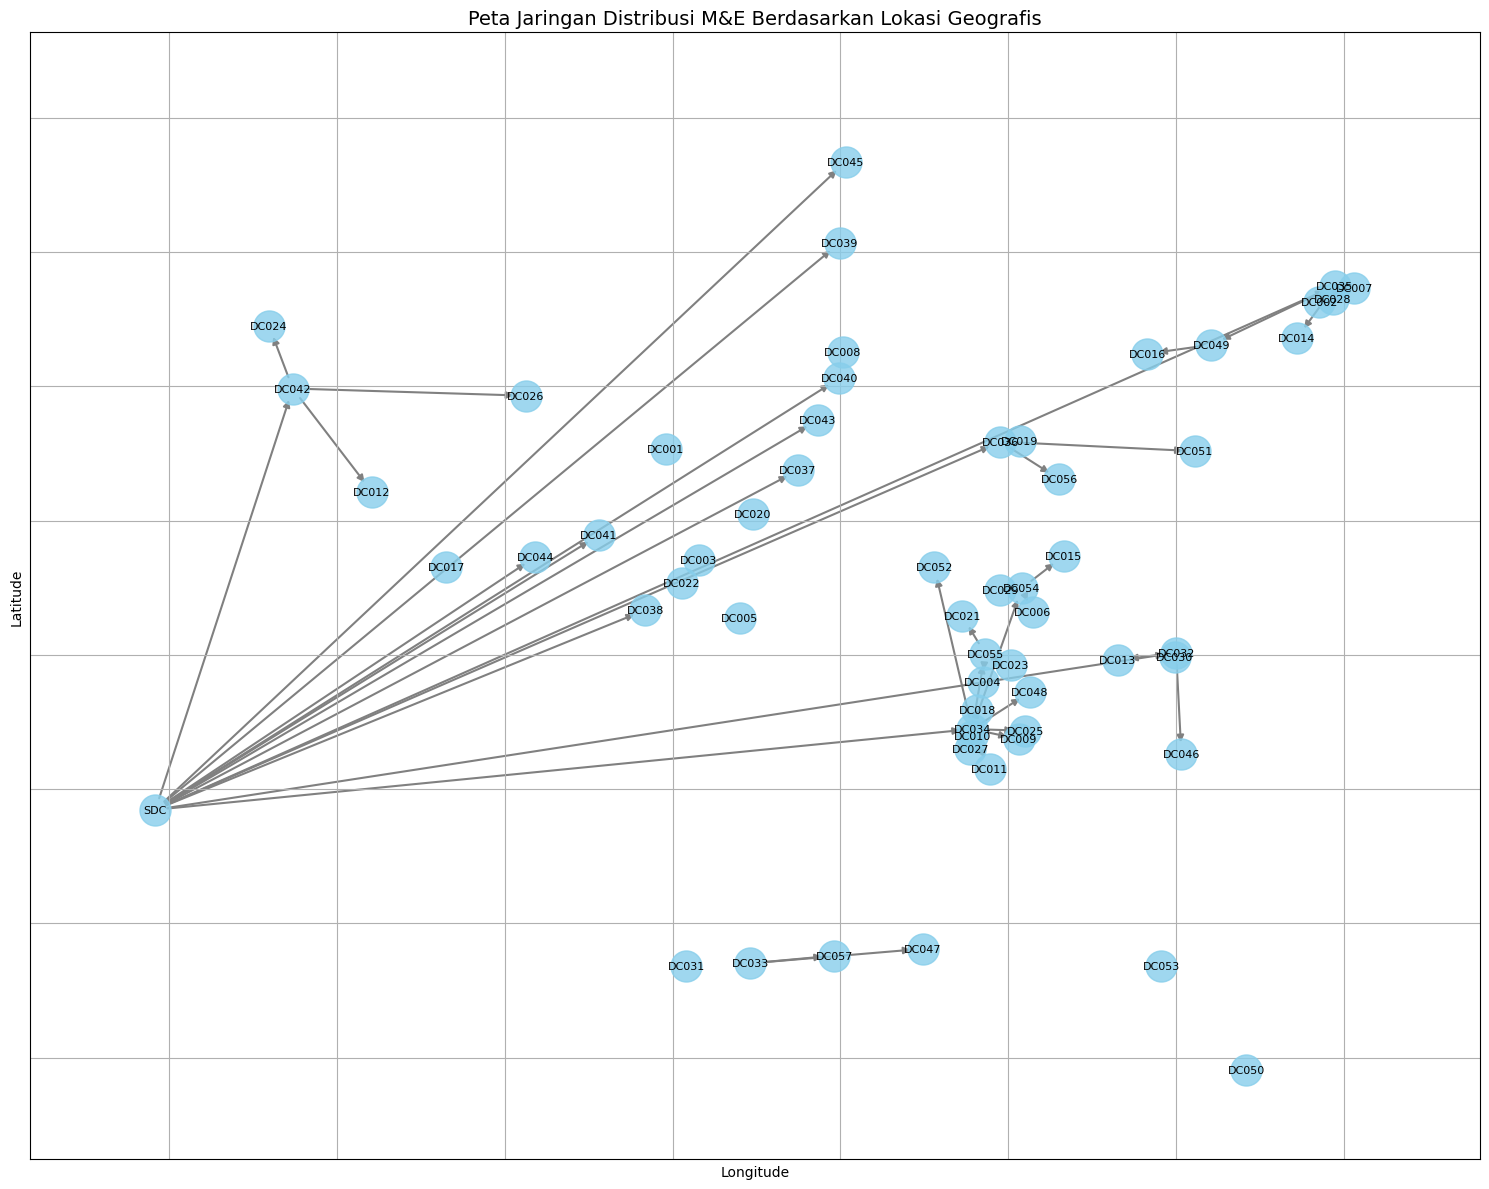

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- STEP 1: Load Dataset ---
xls = pd.ExcelFile("dataset/1742574481558_Dataset-ME-2025.xlsx")
df_dc = pd.read_excel(xls, sheet_name="DC Final")

# --- STEP 2: Preprocessing df_node (semua DC) ---
df_dc.columns = df_dc.columns.str.strip().str.lower().str.replace(" ", "_")

df_node = df_dc[[
    'dc_id', 'type', 'area', 'distributor_area', 'latitude', 'longitude', 'sent_from'
]].dropna(subset=['dc_id', 'latitude', 'longitude'])

df_node = df_node.rename(columns={
    'dc_id': 'node_id',
    'type': 'node_type',
    'area': 'location_name',
    'distributor_area': 'region'
})

# Pastikan latitude & longitude numerik
df_node['latitude'] = df_node['latitude'].astype(str).str.replace(',', '.').astype(float)
df_node['longitude'] = df_node['longitude'].astype(str).str.replace(',', '.').astype(float)

# --- STEP 3: Bangun Graph G ---
G = nx.DiGraph()

# Tambah node
for _, row in df_node.iterrows():
    G.add_node(
        row['node_id'],
        label=row['node_id'],
        type=row['node_type'],
        pos=(row['longitude'], row['latitude'])
    )

# --- Tambahkan node SDC Karawang secara manual ---
karawang_lat = -6.305384
karawang_lon = 107.296913

G.add_node(
    'SDC',
    label='SDC',
    type='Pabrik',
    pos=(karawang_lon, karawang_lat)
)

# --- STEP 4: Buat Dataframe Edge dari sent_from ---
# Map lokasi asal (sent_from) → node_id
location_to_node = dict(zip(df_node['location_name'], df_node['node_id']))

df_edges = df_node[df_node['sent_from'].notna()][['node_id', 'sent_from']].copy()
df_edges = df_edges.rename(columns={'node_id': 'to_node', 'sent_from': 'from_node'})
df_edges['from_node'] = df_edges['from_node'].map(location_to_node)

# Drop baris yang mapping-nya gagal
df_edges = df_edges.dropna(subset=['from_node'])

# Tambah edge ke graf
for _, row in df_edges.iterrows():
    G.add_edge(row['from_node'], row['to_node'])

# Tambahkan edge dari Karawang ke node yang sent_from-nya 'SDC'
karawang_children = df_node[df_node['sent_from'] == 'SDC']['node_id'].tolist()

for to_node in karawang_children:
    G.add_edge('SDC', to_node)


# --- STEP 5: Gambar Peta Jaringan Distribusi ---
pos_geo = {node: data['pos'] for node, data in G.nodes(data=True)}

plt.figure(figsize=(15, 12))

# Gambar node
nx.draw_networkx_nodes(
    G, pos_geo, 
    node_color='skyblue', 
    node_size=500, 
    alpha=0.8
)

# Gambar edge (panah antar DC)
nx.draw_networkx_edges(
    G, pos_geo, 
    edge_color='gray', 
    arrows=True,
    width=1.5
)

# Tambahkan label node
labels = {node: G.nodes[node]['label'] for node in G.nodes}
nx.draw_networkx_labels(
    G, pos_geo, labels,
    font_size=8
)

plt.title("Peta Jaringan Distribusi M&E Berdasarkan Lokasi Geografis", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.axis('equal')  # supaya bentuk geografis tidak melebar
plt.tight_layout()
plt.show()


In [6]:
df_edges = pd.concat([df_land_edges, df_ocean_clean], ignore_index=True)
def classify_mode(mode_str):
    if pd.isna(mode_str):
        return 'Unknown'
    mode_str = str(mode_str).upper()
    if 'FT' in mode_str:
        return 'Ocean'
    return 'Land'

df_edges['mode_type'] = df_edges['mode'].apply(classify_mode)
df_edges.sample(5)



,from_dc,to_area,mode,volume_cbm,cost_idr,mode_type
12,DC032,Pelita,Kontainer Besar,2360,27500000.0,Land
8,DC038,Mawaddah,Kontainer Besar,2360,15535291.0,Land
5,DC037,Cemara,Kontainer Kecil,1160,11214769.0,Land
2,DC033,Anggrek,Bak Terbuka,1600,23500000.0,Land
20,DC036,Berlian,Kontainer Besar,2360,17250000.0,Land


Membuat ocean land final

In [7]:
df_oceanland = df_edges.copy()

# Rename untuk konsistensi
df_oceanland = df_oceanland.rename(columns={
    'from_dc': 'target_node',
    'mode': 'moda',
    'cost_idr': 'cost_per_trip',
    'volume_cbm': 'volume_per_trip'
})

# Tambahkan kolom source_node sebagai SDC
df_oceanland['source_node'] = 'SDC'  # atau nama ID pabrikmu


# Ambil kolom penting untuk df_edges_final
df_oceanland = df_oceanland[['source_node', 'target_node', 'moda', 'cost_per_trip', 'volume_per_trip']]

# Rename untuk konsistensi
df_oceanland = df_oceanland.rename(columns={
    'from_dc': 'target_node',
    'moda': 'mode_type',
    'cost_idr': 'cost_per_trip',
    'volume_cbm': 'volume_per_trip'
})

df_oceanland.head()

,source_node,target_node,mode_type,cost_per_trip,volume_per_trip
0,SDC,DC031,Bak Terbuka,12500000.0,1600
1,SDC,DC031,Truk Besar,8682800.0,880
2,SDC,DC033,Bak Terbuka,23500000.0,1600
3,SDC,DC033,Truk Sedang,13000000.0,280
4,SDC,DC033,Truk Besar,17500000.0,880


Membuat rute middle mile

In [8]:
import pandas as pd
from geopy.distance import geodesic

# 1. Load data
file_path = "dataset/E2099100.xlsx"
df_middle = pd.read_excel(file_path, sheet_name="Middle Mile")

# 2. Convert kolom koordinat ke float
coord_cols = ['Origin Latitude', 'Longitude_x', 'Destination Latitude', 'Destination Longitude']
for col in coord_cols:
    df_middle[col] = pd.to_numeric(df_middle[col], errors='coerce')  # coerce biar error jadi NaN


df_middle.sample(10)

,Distributor Area,Origin Area,Origin Latitude,Longitude_x,Destination Area,Destination Latitude,Destination Longitude,Volume (CS)
737,Sulawesi,Unaaha,-4.03681,122.48113,Barru,-4.40562,119.61877,50
277,Sulawesi,Kendari,-3.96513,122.50127,Palu,-0.82320,119.88515,1000
396,Sulawesi,Barru,-4.40562,119.61877,Bitung,1.47110,125.15311,50
479,Sulawesi,Gowa,-5.20514,119.46374,Marisa,0.48671,122.07034,50
753,Sulawesi,Unaaha,-4.03681,122.48113,Tomohon,1.29712,124.83620,50
935,Sulawesi,Palopo,-3.00675,120.20264,Amurang,1.25533,124.63187,100
295,Sulawesi,Makassar,-5.10404,119.46298,Bau-Bau,-5.48159,122.58000,500
872,Sulawesi,Bone,-4.55181,120.32640,Tomohon,1.29712,124.83620,100
398,Sulawesi,Barru,-4.40562,119.61877,Gowa,-5.20514,119.46374,50
967,Sulawesi,Pare-Pare,-3.97929,119.65472,Parigi,-0.81564,120.17009,100


In [9]:
# 3. Drop baris yang koordinatnya tidak valid
df_middle_cleaned = df_middle.dropna(subset=coord_cols)

# 4. Hitung jarak
df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
    lambda row: geodesic(
        (row['Origin Latitude'], row['Longitude_x']),
        (row['Destination Latitude'], row['Destination Longitude'])
    ).km,
    axis=1
)
df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)

# 5. Lihat hasil
print(df_middle_cleaned[['Origin Area', 'Destination Area', 'distance_km']].sample(10))


        Origin Area Destination Area  distance_km
645        Sengkang        Bulukumba       123.27
81   Penajam-Grogot         Ketapang       632.68
618          Parigi          Takalar       513.14
478            Gowa       Mangkutana       332.62
774         Kendari           Unaaha         8.24
186          Sampit  Bontang-Sangata       610.49
211     Banjarmasin       Balikpapan       341.82
764         Kendari       Mangkutana       245.14
622          Polman          Amurang       785.53
721          Toraja        Bulukumba       247.69


C:\Users\nesha\AppData\Local\Temp\ipykernel_23728\1122828425.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned.apply(
C:\Users\nesha\AppData\Local\Temp\ipykernel_23728\1122828425.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_middle_cleaned['distance_km'] = df_middle_cleaned['distance_km'].round(2)


In [10]:
# Merge df_node dengan df_edges
df_dc_olCost = df_node.merge(
    df_edges,
    left_on='node_id',
    right_on='from_dc',
    how='left'
)

# Drop kolom 'from_dc' dan 'to_area' dari hasil merge
df_dc_olCost = df_dc_olCost.drop(columns=['from_dc', 'to_area'])

# Cek hasil
df_dc_olCost.sample(10)



,node_id,node_type,location_name,region,latitude,longitude,sent_from,mode,volume_cbm,cost_idr,mode_type
45,DC038,Direct DC,Banjarmasin,Kalimantan,-3.330249,114.595582,SDC,Kontainer Kecil,1160,10071150.0,Land
1,DC002,Depo,Amurang,BCP Outer,1.255330,124.631870,Manado,NaN,NaN,NaN,NaN
15,DC016,Depo,Marisa,BCP Outer,0.486710,122.070340,Gorontalo,NaN,NaN,NaN,NaN
56,DC044,Direct DC,Sampit,Kalimantan,-2.538901,112.956601,SDC,Kontainer Besar,2360,26680606.0,Land
14,DC015,Depo,Mangkutana,BCP Outer,-2.525350,120.824050,Palopo,NaN,NaN,NaN,NaN
42,DC036,Direct CPU,Palu,BCP Outer,-0.823200,119.885150,SDC,Kontainer Besar,2360,17250000.0,Land
49,DC041,Direct DC,Palangkaraya,Kalimantan,-2.218321,113.900455,SDC,Kontainer Kecil,1160,13705881.0,Land
28,DC029,Depo,Toraja,BCP Outer,-3.029200,119.881900,Palopo,NaN,NaN,NaN,NaN
29,DC030,Depo,Unaaha,BCP Outer,-4.036810,122.481130,Kendari,NaN,NaN,NaN,NaN
21,DC022,Depo,Rantau,Kalimantan,-2.934015,115.141980,NaN,NaN,NaN,NaN,NaN


In [11]:
import pandas as pd

# Step 1: Buat mapping location_name → DC ID
location_to_dc_id = df_dc_olCost.set_index('location_name')['node_id'].to_dict()

# Step 2: Salin df_middle_cleaned biar tidak ubah yang asli
df_middle_edges = df_middle_cleaned.copy()

# Step 3: Mapping ke DC ID
df_middle_edges['origin_id'] = df_middle_edges['Origin Area'].map(location_to_dc_id)
df_middle_edges['destination_id'] = df_middle_edges['Destination Area'].map(location_to_dc_id)

# Step 4: Cek mapping yang gagal
missing_origin = df_middle_edges[df_middle_edges['origin_id'].isna()]
missing_dest = df_middle_edges[df_middle_edges['destination_id'].isna()]

print("🚨 Origin Area yang tidak ditemukan:")
print(missing_origin[['Origin Area']].drop_duplicates())

print("\n🚨 Destination Area yang tidak ditemukan:")
print(missing_dest[['Destination Area']].drop_duplicates())

# Step 5: Drop baris yang tidak berhasil mapping
df_middle_edges_cleaned = df_middle_edges.dropna(subset=['origin_id', 'destination_id']).copy()

# Step 6: Buat edge list final
df_middle_edge_list = df_middle_edges_cleaned[[
    'origin_id',
    'destination_id',
    'distance_km',
    'Volume (CS)'  # atau 'volume_cbm' tergantung kolom kamu
]].rename(columns={
    'distance_km': 'distance_km',
    'Volume (CS)': 'max_volume'
})

print("\n✅ Contoh edge list middle mile:")
print(df_middle_edge_list.sample(5))


🚨 Origin Area yang tidak ditemukan:
Empty DataFrame
Columns: [Origin Area]
Index: []

🚨 Destination Area yang tidak ditemukan:
Empty DataFrame
Columns: [Destination Area]
Index: []

✅ Contoh edge list middle mile:
    origin_id destination_id  distance_km max_volume
671     DC025          DC018        86.16         50
723     DC029          DC011       295.99         50
711     DC028          DC021       805.77         50
203     DC037          DC038       341.82       1000
819     DC036          DC009       490.65        100


In [12]:
df_middle_edge_list.head()

,origin_id,destination_id,distance_km,max_volume
0,DC031,DC033,105.38,1000
1,DC033,DC031,105.38,1000
2,DC031,DC047,388.99,500
3,DC031,DC050,932.41,500
4,DC031,DC053,778.61,500


In [13]:
df_resources = pd.read_excel("dataset/1742574481558_Dataset-ME-2025.xlsx", sheet_name="Resources", skiprows=3)

# Rename
df_resources.columns = [
    "Region", "Branch",
    "CDD", "CDE", "GrandMax", "Kijang",
    "Unused1",
    "Driver", "Staff",
    "CDD Cost", "CDE Cost", "GrandMax Cost", "Kijang Cost", "Driver Cost", "Staff Cost",
    "CDD Total", "CDE Total", "GrandMax Total", "Kijang Total", "Driver Total",
    "Unused2",
    "Fleet Fixed Cost/Day", "Fleet Variable Cost/Day", "People Cost/Day",
    "Transport All In/Day", "Capacity"
]

# Drop kolom yang tidak dipakai
df_resources.drop(columns=["Unused1", "Unused2"], inplace=True)

# Pastikan kolom numerik jadi float
numeric_cols = df_resources.columns.difference(["Region", "Branch"])
df_resources[numeric_cols] = df_resources[numeric_cols].fillna(0).astype(float)

df_resources.head()


,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDD Total,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,0.0,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,6900000.0,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,20700000.0,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,0.0,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,13800000.0,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0


In [14]:
# 1. Buat salinan kolom yang akan dibandingkan
df_resources['Branch_lower'] = df_resources['Branch'].str.lower().str.strip()
df_dc['Area_lower'] = df_dc['area'].str.lower().str.strip()

# 2. Merge pakai versi lowercase
df_resources_joined = df_resources.merge(
    df_dc[['Area_lower', 'dc_id']],
    left_on='Branch_lower',
    right_on='Area_lower',
    how='left'
)

# 3. Drop kolom bantu kalau sudah tidak dipakai
df_resources_joined.drop(columns=['Branch_lower', 'Area_lower'], inplace=True)

# 4. Lihat hasil join
df_resources_joined.head()


,Region,Branch,CDD,CDE,GrandMax,Kijang,Driver,Staff,CDD Cost,CDE Cost,...,CDE Total,GrandMax Total,Kijang Total,Driver Total,Fleet Fixed Cost/Day,Fleet Variable Cost/Day,People Cost/Day,Transport All In/Day,Capacity,dc_id
0,BNT,Bima,0.0,2.0,0.0,0.0,3.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,11269866.0,4.230769e+05,400000.0,4.334564e+05,1.256533e+06,400.0,DC047
1,BNT,Lombok,1.0,6.0,1.0,0.0,18.0,9.0,6900000.0,5500000.0,...,33000000.0,3500000.0,0.0,67619196.0,1.669231e+06,1600000.0,2.600738e+06,5.869969e+06,1600.0,DC033
2,BNT,Kupang,3.0,2.0,0.0,0.0,8.0,4.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,30052976.0,1.219231e+06,1000000.0,1.155884e+06,3.375114e+06,1240.0,DC050
3,BNT,Sumbawa,0.0,1.0,1.0,0.0,4.0,3.0,6900000.0,5500000.0,...,5500000.0,3500000.0,0.0,15026488.0,3.461538e+05,400000.0,5.779418e+05,1.324096e+06,320.0,DC057
4,BNT,Maumere,2.0,2.0,0.0,0.0,5.0,3.0,6900000.0,5500000.0,...,11000000.0,0.0,0.0,18783110.0,9.538462e+05,800000.0,7.224273e+05,2.476273e+06,960.0,DC053


In [15]:
import pandas as pd

# 1. Load Excel
file_path = "dataset/Dataset Bersih Lengkap.xlsx"
df_dc = pd.read_excel(file_path, sheet_name="DC Final")
df_stp = pd.read_excel(file_path, sheet_name="STP Performance")

# 2. Ambil area-area dari masing-masing sheet
# - Dari DC Final
df_dc_clean = df_dc.copy()
df_dc_clean['Area_clean'] = df_dc_clean['Area'].astype(str).str.strip().str.lower()

area_manual_map = {
    "Bali": "Denpasar",        # Bali → Denpasar
    # tambahkan jika ada kasus lain nanti
}


# - Dari STP Performance
df_stp_clean = df_stp.copy()
df_stp_clean['Area_clean'] = df_stp_clean['Area'].astype(str).str.strip().str.lower()

# 3. Gabungkan berdasarkan area yang dibersihkan
df_merged = pd.merge(df_stp_clean, df_dc_clean[['DC ID', 'Area_clean']], on='Area_clean', how='left')

# 4. Tampilkan hasil yang belum match
df_unmatched = df_merged[df_merged['DC ID'].isna()]

print("🟡 Jumlah STP yang berhasil match ke DC ID:", len(df_merged) - len(df_unmatched))
print("🔴 Jumlah STP yang belum berhasil match:", len(df_unmatched))
print("\nContoh STP yang belum match:\n", df_unmatched[['Ship to Point', 'Area']].head())


🟡 Jumlah STP yang berhasil match ke DC ID: 15
🔴 Jumlah STP yang belum berhasil match: 0

Contoh STP yang belum match:
 Empty DataFrame
Columns: [Ship to Point, Area]
Index: []


In [16]:
# 0. Manual mapping untuk area yang tidak match
area_manual_map = {
    "bali": "denpasar",        # Bali → Denpasar
    # tambahkan jika ada kasus lain nanti
}

# 1. Terapkan mapping ke df_stp_clean
df_stp_clean['Area_mapped'] = df_stp_clean['Area_clean'].apply(lambda x: area_manual_map.get(x, x))

# 2. Merge ulang pakai Area_mapped
df_merged = pd.merge(df_stp_clean, df_dc_clean[['DC ID', 'Area_clean']], left_on='Area_mapped', right_on='Area_clean', how='left')

# 3. Cek unmatched
df_unmatched = df_merged[df_merged['DC ID'].isna()]

print("🟢 Jumlah STP yang berhasil match setelah mapping:", len(df_merged) - len(df_unmatched))
print("🔴 Jumlah STP yang masih belum match:", len(df_unmatched))
print("\nContoh STP yang belum match:\n", df_unmatched[['Ship to Point', 'Area']].head())


🟢 Jumlah STP yang berhasil match setelah mapping: 15
🔴 Jumlah STP yang masih belum match: 0

Contoh STP yang belum match:
 Empty DataFrame
Columns: [Ship to Point, Area]
Index: []


In [17]:
import pandas as pd

# Contoh: load data dari Excel (ubah sesuai kebutuhanmu)
df_stp = pd.read_excel(xls, sheet_name="STP Performance")

# Jika sudah berupa DataFrame df_stp:
def parse_order_schedule(order_schedule):
    # Bersihkan spasi dan pisah berdasarkan koma atau strip
    days = []
    if pd.isna(order_schedule):
        return []
    parts = order_schedule.replace('-', ',').replace(' ', '').split(',')
    for p in parts:
        if p != '':
            days.append(p.strip().capitalize())  # capitalized (Mon, Tue, ...)
    return days

def transform_stp_to_order_constraints(df_stp):
    # Rename kolom agar lebih seragam
    df = df_stp.rename(columns={
        'DC ID': 'target_node',
        'Current Lead Time\nSO/LO': 'lead_time_days',
        'Order \nSchedule': 'order_schedule',
        'Order/Wk': 'order_wk'
    })

    # Parse kolom hari kirim
    df['valid_days'] = df['order_schedule'].apply(parse_order_schedule)

    # Ambil kolom penting
    df_out = df[['target_node', 'order_wk', 'valid_days', 'lead_time_days']].copy()

    # Normalisasi node name (opsional, misal: uppercase)
    df_out['target_node'] = df_out['target_node'].str.upper().str.strip()

    return df_out

# Contoh pemakaian:
df_order_constraints = transform_stp_to_order_constraints(df_merged)
df_order_constraints.head()


,target_node,order_wk,valid_days,lead_time_days
0,DC031,3,"[Mon, Sat]",7
1,DC032,2,"[Mon, Sat]",14
2,DC033,2,"[Mon, Sat]",9
3,DC034,3,"[Mon, Sat]",14
4,DC035,2,"[Mon, Sat]",20


In [18]:
df_merged.head()

,Account,#,Ship to #,Ship to Point,Area,Current Lead Time\nSO/LO,Order \nSchedule,Order/Wk,Volume Performance (cbm) per Order - P6M,Area_clean_x,Area_mapped,DC ID,Area_clean_y
0,NaN,1.0,NaN,NaN,Kencana,7,Mon - Sat,3,NaN,kencana,kencana,DC031,kencana
1,NaN,3.0,NaN,NaN,Pelita,14,Mon - Sat,2,NaN,pelita,pelita,DC032,pelita
2,NaN,4.0,NaN,NaN,Anggrek,9,Mon - Sat,2,NaN,anggrek,anggrek,DC033,anggrek
3,NaN,5.0,NaN,NaN,Sakura,14,Mon - Sat,3,NaN,sakura,sakura,DC034,sakura
4,NaN,6.0,NaN,NaN,Delima,20,Mon - Sat,2,NaN,delima,delima,DC035,delima


In [19]:
df_stp.head()

,Account,#,Ship to #,Ship to Point,Area,Current Lead Time\nSO/LO,Order \nSchedule,Order/Wk,Volume Performance (cbm) per Order - P6M,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,BCP A,1.0,2000277541,BORWITA CITRA PRIMA - BALI,Bali,7,Mon - Sat,3,CPU,NaN,NaN,NaN
1,BCP A,3.0,2002052726,PT. BORWITA CITRA PRIMA - KENDARI,Kendari,14,Mon - Sat,2,CPU,NaN,NaN,NaN
2,BCP A,4.0,2002064353,PT. BORWITA CITRA PRIMA - LOMBOK,Lombok,9,Mon - Sat,2,CPU,NaN,NaN,NaN
3,BCP A,5.0,2000874584,BORWITA CITRA PRIMA MAKASAR,Makassar,14,Mon - Sat,3,CPU,NaN,NaN,NaN
4,BCP A,6.0,2000876000,BORWITA CITRA PRIMA-MANADO,Manado,20,Mon - Sat,2,CPU,NaN,NaN,NaN


In [20]:
vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'Kijang']
mode_param = {
    'CDD': 70,
    'CDE': 100,
    'GrandMax': 120,
    'Kijang': 50
}

# Simulasi data
# df_resource_joined = df_resources.copy()

# Bersihkan dan bentuk long format dari df_resource_joined
resource_edges_v2 = []
for _, row in df_resources_joined.iterrows():
    origin = row['dc_id']
    if pd.isna(origin):
        continue
    for mode in vehicle_modes:
        jumlah = row[mode]
        cost = row[f'{mode} Cost']
        if pd.notna(jumlah) and pd.notna(cost) and jumlah > 0 and cost > 0:
            resource_edges_v2.append({
                'source_node': origin,
                'mode_type': mode,
                'cost_per_trip': cost,
                'volume_per_trip': mode_param[mode]
            })

df_mode_per_dc_v2 = pd.DataFrame(resource_edges_v2)

# Gabungkan ke df_middle_edge_list
df_middle_expanded_v2 = df_middle_edge_list.merge(
    df_mode_per_dc_v2,
    left_on='origin_id',
    right_on='source_node',
    how='left'
)

# Filter hanya kombinasi valid
df_middle_final_v2 = df_middle_expanded_v2.dropna(subset=['mode_type'])

# Ambil kolom final
df_middle_edges_final_v2 = df_middle_final_v2[['source_node', 'destination_id', 'mode_type', 'cost_per_trip', 'volume_per_trip']]
df_middle_edges_final_v2 = df_middle_edges_final_v2.rename(columns={'destination_id': 'target_node'})

df_middle_edges_final_v2.sample(5)

,source_node,target_node,mode_type,cost_per_trip,volume_per_trip
1159,DC034,DC002,CDE,5500000.0,100.0
1273,DC036,DC013,CDE,5500000.0,100.0
1185,DC034,DC021,CDE,5500000.0,100.0
1157,DC032,DC030,CDE,5500000.0,100.0
24,DC050,DC047,CDE,5500000.0,100.0


In [21]:
# Gabungkan df_oceanland (first mile) dengan df_middle_edges_final_v2 (middle mile)
df_edges_final = pd.concat([df_oceanland, df_middle_edges_final_v2], ignore_index=True)

# Tampilkan hasil
df_edges_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1136 entries, 0 to 1135
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_node      1136 non-null   object 
 1   target_node      1136 non-null   object 
 2   mode_type        1136 non-null   object 
 3   cost_per_trip    1136 non-null   float64
 4   volume_per_trip  1136 non-null   object 
dtypes: float64(1), object(4)
memory usage: 44.5+ KB


In [22]:
df_demand = pd.read_csv("dataset/demand_per_dc_no_capacity.csv")
df_demand.head()

,DC ID,Total Demand (box)
0,DC001,2617.487149
1,DC002,1451.503244
2,DC003,6052.556426
3,DC004,839.895140
4,DC005,3655.658944


In [23]:
import pandas as pd

# Path ke file
file_path = "dataset/Dataset Bersih Lengkap.xlsx"

# Baca sheet 'DC Final'
df_dc = pd.read_excel(file_path, sheet_name="DC Final")

# Tampilkan beberapa baris awal
print(df_dc.head())


      Area  DC ID Distributor  Distributor Area   Area.1  Type Sent From  \
0  Purnama  DC001          GF               NaN  Purnama  Depo    Cemara   
1    Surya  DC002          AL               NaN    Surya  Depo    Delima   
2  Tembaga  DC003          GF               NaN  Tembaga  Depo  Mawaddah   
3   Sagara  DC004          AL               NaN   Sagara  Depo    Madani   
4  Lestari  DC005          GF               NaN  Lestari  Depo  Mawaddah   

   Address  Latitude   Longitude  ...  Capacity  Unnamed: 24 Bali  9800  \
0      NaN -0.935414  114.901123  ...         0          NaN  NaN   NaN   
1      NaN  1.255330  124.631870  ...         0          NaN  NaN   NaN   
2      NaN -2.581936  115.390569  ...         0          NaN  NaN   NaN   
3      NaN -4.405620  119.618770  ...         0          NaN  NaN   NaN   
4      NaN -3.455801  115.997490  ...         0          NaN  NaN   NaN   

   Unnamed: 27  Kalimantan  23600  Unnamed: 30  Sulawesi  16080  
0          NaN         NaN

In [24]:
import pandas as pd
import numpy as np

# Load data demand dan kapasitas
df_demand = pd.read_csv("dataset/demand_per_dc_no_capacity.csv")
df_capacity = df_resources_joined[["dc_id", "Capacity"]].copy()
df_capacity.columns = ["DC ID", "Capacity"]  # rename biar konsisten

# Gabungkan berdasarkan DC ID
df_turnover = df_demand.merge(df_capacity, on="DC ID", how="left")

# Drop baris yang tidak punya info kapasitas
df_turnover = df_turnover.dropna(subset=["Capacity"])

# Hitung turnover (jumlah kali perputaran gudang dalam sebulan)
df_turnover["Turnover Per Bulan"] = np.ceil(df_turnover["Total Demand (box)"] / df_turnover["Capacity"]).astype(int)

# Flag Over Capacity
df_turnover["Over Capacity"] = df_turnover["Total Demand (box)"] > df_turnover["Capacity"]

# Output hasil
print(df_turnover[["DC ID", "Total Demand (box)", "Capacity", "Turnover Per Bulan", "Over Capacity"]])


    DC ID  Total Demand (box)  Capacity  Turnover Per Bulan  Over Capacity
31  DC032         5633.492797    1640.0                   4           True
32  DC033        15308.986194    1600.0                  10           True
33  DC034         7533.841607    2920.0                   3           True
34  DC035         5809.725317    3400.0                   2           True
35  DC036         6917.255792    1560.0                   5           True
36  DC037         7718.457694    2880.0                   3           True
37  DC038        10607.940620    5280.0                   3           True
38  DC039         2738.203119     520.0                   6           True
40  DC041         3973.833266    1040.0                   4           True
42  DC043        10341.133525    1800.0                   6           True
43  DC044         3964.283106    1000.0                   4           True
44  DC045         6447.970229     520.0                  13           True
45  DC046         2484.05

Bangun Model (unmet nya 3.000+++)

In [25]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # <-- Tambahkan ini di atas

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Assumed preloaded) ---
# Required DataFrames: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints

vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80
}
PENALTY_RATE = 1000000000

WORKING_HOURS_PER_DAY = 10
DAYS_IN_MONTH = 24
TOTAL_WORKING_HOURS = WORKING_HOURS_PER_DAY * DAYS_IN_MONTH  # 240 jam


# Convert numeric fields
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

# --- Paksa update volume_per_trip di df_edges_final sesuai mode_param ---
df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()  # buang spasi
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol


# Dictionaries
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

volume_cap_dict = {
    (r.origin_id, r.destination_id): int(round(r.max_volume))
    for _, r in df_middle_edge_list.iterrows() if pd.notna(r.max_volume)
}

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

lead_time_dict = {
    r['target_node']: int(r['lead_time_days'])
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

# --- Update kapasitas kendaraan per mode sesuai mode_param ---
for mode, new_val in mode_param.items():
    if mode in df_resources_joined.columns:
        df_resources_joined.loc[df_resources_joined[mode].notna(), mode] = new_val


trip_limit = {}
for _, row in df_resources_joined.iterrows():

    dc = row['dc_id']
    for mode in vehicle_modes:
        if pd.notna(row.get(mode)):
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 9999  # nilai besar agar tidak membatasi

            
# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1)
    dem = demand_dict.get(j, 1_000_000)
    x[i, j, m] = model.NewIntVar(0, math.ceil(dem / vol), f"x_{i}_{j}_{m}")
    
# --- Replace kapasitas dengan turnover per bulan jika tersedia ---
turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * row['Turnover Per Bulan']))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}



# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list)
incoming_vars = defaultdict(list)
sdctrip_vars = defaultdict(list)
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge_list.origin_id, df_middle_edge_list.destination_id))

WORKING_DAYS_PER_MONTH = 24
WORKING_HOURS_PER_DAY = 10

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    if i.startswith("SDC"):
        sdctrip_vars[j].append(var)

    # --- Constraint: Kapasitas Volume dari edge
    if (i, j) in volume_cap_dict:
        model.Add(var * vol <= volume_cap_dict[(i, j)] * WORKING_DAYS_PER_MONTH)

    # --- Constraint: Lead Time × Working Hours (NEW)
    lead = lead_time_dict.get((i, j))

    if lead:
        # hitung jumlah kendaraan di DC asal (berdasarkan trip_limit)
        n_vehicle = trip_limit.get((i, m), 0) // WORKING_DAYS_PER_MONTH
        total_hours = n_vehicle * WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
        max_trip = total_hours // (2 * lead)
        model.Add(var <= max_trip)

    # --- Constraint: Valid Route
    if (i, j) not in valid_routes:
        model.Add(var == 0)

# --- Constraint: total trip per (i, mode)
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])

# --- Constraint: SDC ke DC order constraint mingguan
for j, vars_list in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(vars_list) <= order_limit[j])

# --- Constraint: total volume in per DC
for j, varlist in incoming_vars.items():
    if j in demand_dict:
        model.Add(sum(var * vol for var, vol in varlist) <= demand_dict[j])

    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))  # Prioritaskan turnover
    model.Add(sum(var * vol for var, vol in varlist) <= capacity)



# --- 4. OBJECTIVE ---
cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]
penalty_terms = []

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, demand, f"sent_{j}")
    model.Add(sent == sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                          for (i, j2, m) in x if j2 == j))
    unmet_var = model.NewIntVar(0, demand, f"unmet_{j}")
    model.Add(unmet_var == demand - sent)
    penalty_terms.append(unmet_var * PENALTY_RATE)
    unmet[j] = unmet_var  # <-- simpan dalam dictionary


model.Minimize(sum(cost_terms) + sum(penalty_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 10
status = solver.Solve(model)

# --- 6. OUTPUT ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total

print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

# Hitung total unmet demand (dari variabel "unmet" yang kamu buat waktu penalti_terms)
total_unmet = sum(solver.Value(unmet[j]) for j in demand_dict)
total_penalty = total_unmet * PENALTY_RATE

print(f"🚫 Total Unmet Demand: {total_unmet:,} box")
print(f"💣 Total Penalti: Rp {total_penalty:,.0f}")
print(f"🧾 Biaya Total Akhir (Distribusi + Denda): Rp {total_cost + total_penalty:,.0f}")


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    debug.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim
    })

df_debug = pd.DataFrame(debug).sort_values(by='Unmet', ascending=False)

# Tampilkan 10 DC dengan unmet demand terbesar
print(df_debug.head(10).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # ambil 5 DC teratas
    print(f"\n[DC: {j}]")
    
    # --- Cek rute masuk ---
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips = solver.Value(x[i, j, m])
        max_trip_limit = trip_limit.get((i, m), 0)
        lead = lead_time_dict.get(j, None)
        max_trip_lead = (DAYS_IN_MONTH // (2 * lead)) * max_trip_limit if lead else '–'

        route_valid = (i, j) in valid_routes
        vol_cap = volume_cap_dict.get((i, j), None)
        vol_cap_text = f"{vol_cap * DAYS_IN_MONTH:,}" if vol_cap else "–"

        print(f"- {i} → {j} via {m}:")
        print(f"  ✔ route valid? {route_valid}")
        print(f"  🚚 trips used: {trips:,}")
        print(f"  📦 vol/trip: {vol:,}")
        print(f"  💼 trip_limit: {max_trip_limit:,}")
        print(f"  ⏱ max_trip by lead: {max_trip_lead}")
        print(f"  🛣 max_vol via edge: {vol_cap_text}")



✅ Solusi ditemukan.

🚚 Trip Aktif dalam Solusi:
--------------------------------------------------
SDC → DC031 via Bak Terbuka | trip = 12 | cost/trip = Rp 12,500,000 | total cost = Rp 150,000,000 | volume = 19,200
SDC → DC033 via Bak Terbuka | trip = 8 | cost/trip = Rp 23,500,000 | total cost = Rp 188,000,000 | volume = 12,800
SDC → DC037 via Kontainer Besar | trip = 3 | cost/trip = Rp 19,584,837 | total cost = Rp 58,754,511 | volume = 7,080
SDC → DC038 via Kontainer Kecil | trip = 1 | cost/trip = Rp 10,071,150 | total cost = Rp 10,071,150 | volume = 1,160
SDC → DC038 via Kontainer Besar | trip = 4 | cost/trip = Rp 15,535,291 | total cost = Rp 62,141,164 | volume = 9,440
SDC → DC039 via Kontainer Kecil | trip = 2 | cost/trip = Rp 17,082,458 | total cost = Rp 34,164,916 | volume = 2,320
SDC → DC040 via Kontainer Kecil | trip = 1 | cost/trip = Rp 17,095,210 | total cost = Rp 17,095,210 | volume = 1,160
SDC → DC032 via Kontainer Besar | trip = 2 | cost/trip = Rp 27,500,000 | total cost =

In [26]:
print("\n📦 Semua (i, j, m) aktif:")
for (i, j, m) in x:
    if j == "DC037" or j == "DC038":
        print(f"{i} → {j} via {m}")



📦 Semua (i, j, m) aktif:
SDC → DC037 via Kontainer Kecil
SDC → DC037 via Kontainer Besar
SDC → DC038 via Kontainer Kecil
SDC → DC038 via Kontainer Besar
DC037 → DC038 via CDD
DC037 → DC038 via CDE
DC037 → DC038 via GrandMax
DC038 → DC037 via CDD
DC038 → DC037 via CDE
DC038 → DC037 via GrandMax
DC039 → DC037 via CDD
DC039 → DC037 via GrandMax
DC039 → DC038 via CDD
DC039 → DC038 via GrandMax
DC041 → DC037 via CDD
DC041 → DC037 via CDE
DC041 → DC037 via GrandMax
DC041 → DC038 via CDD
DC041 → DC038 via CDE
DC041 → DC038 via GrandMax
DC043 → DC037 via CDD
DC043 → DC037 via CDE
DC043 → DC037 via GrandMax
DC043 → DC038 via CDD
DC043 → DC038 via CDE
DC043 → DC038 via GrandMax
DC044 → DC037 via CDD
DC044 → DC037 via CDE
DC044 → DC037 via GrandMax
DC044 → DC038 via CDD
DC044 → DC038 via CDE
DC044 → DC038 via GrandMax
DC045 → DC037 via CDE
DC045 → DC037 via GrandMax
DC045 → DC037 via Kijang
DC045 → DC038 via CDE
DC045 → DC038 via GrandMax
DC045 → DC038 via Kijang


REVISIII BROWWW

In [27]:
# Backup sebelum diubah
df_middle_backup = df_middle_edge_list.copy()
df_middle_used= df_middle_backup
# 2. Index biar gampang lookup jarak
df_middle_edge_list.set_index(['origin_id', 'destination_id'], inplace=True)

In [28]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # <-- Tambahkan ini di atas

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Assumed preloaded) ---
# Required DataFrames: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints

vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80
}
PENALTY_RATE = 1000000000

WORKING_HOURS_PER_DAY = 10
WORKING_DAYS_PER_MONTH = 24
TOTAL_WORKING_HOURS = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH  # 240 jam

# Convert numeric fields
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

# --- Paksa update volume_per_trip di df_edges_final sesuai mode_param ---
df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()  # buang spasi
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol


# Dictionaries
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

lead_time_dict_sdc = {
    ("SDC", r['target_node']): int(r['lead_time_days']) * 24
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

# 1. Mapping speed kendaraan
speed_by_mode = {
    'GrandMax': 40,
    'Kijang': 50,
    'CDE': 45,
    'CDD': 45,
    'FUSO': 35
}




# 3. Buat dictionary lead_time_dict_dc berdasarkan rute antar DC dan mode
lead_time_dict_dc = {}

for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    if (i, j) in df_middle_edge_list.index:
        dist_km = df_middle_edge_list.loc[(i, j), 'distance_km']
        speed = speed_by_mode.get(m, 40)  # default 40 km/jam kalau mode gak dikenal
        if pd.notna(dist_km) and speed > 0:
            lead_time = int(round(dist_km / speed))
            lead_time_dict_dc[(i, j, m)] = lead_time


lead_time_dict = {**lead_time_dict_sdc, **lead_time_dict_dc}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

volume_cap_dict = {
    (r['origin_id'], r['destination_id']): int(round(r['max_volume']))
    for _, r in df_middle_used.reset_index().iterrows()
    if pd.notna(r['max_volume'])
}

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}



order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

# --- Update kapasitas kendaraan per mode sesuai mode_param ---
for mode, new_val in mode_param.items():
    if mode in df_resources_joined.columns:
        df_resources_joined.loc[df_resources_joined[mode].notna(), mode] = new_val


trip_limit = {}
for _, row in df_resources_joined.iterrows():

    dc = row['dc_id']
    for mode in vehicle_modes:
        if pd.notna(row.get(mode)):
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 9999  # nilai besar agar tidak membatasi

            
# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1)
    dem = demand_dict.get(j, 1_000_000)
    x[i, j, m] = model.NewIntVar(0, math.ceil(dem / vol), f"x_{i}_{j}_{m}")
    
# --- Replace kapasitas dengan turnover per bulan jika tersedia ---
turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * row['Turnover Per Bulan']))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}


df_middle_edge = df_middle_backup.copy()



# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list)
incoming_vars = defaultdict(list)
sdctrip_vars = defaultdict(list)
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge.origin_id, df_middle_edge.destination_id))

WORKING_DAYS_PER_MONTH = 24
WORKING_HOURS_PER_DAY = 10

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    if i.startswith("SDC"):
        sdctrip_vars[j].append(var)

    # --- Constraint: Kapasitas Volume dari edge
    if (i, j) in volume_cap_dict:
        model.Add(var * vol <= volume_cap_dict[(i, j)] * WORKING_DAYS_PER_MONTH)

    # --- Constraint: Lead Time × Working Hours (NEW)
    lead = lead_time_dict.get((i, j), lead_time_dict.get((i, j, m)))

# Hanya tambahkan constraint lead time jika BUKAN dari SDC
    if lead and not i.startswith("SDC"):
        n_vehicle = trip_limit.get((i, m), 0) // WORKING_DAYS_PER_MONTH
        total_hours = n_vehicle * WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
        max_trip = total_hours // (2 * lead)
        model.Add(var <= max_trip)


    # --- Constraint: Valid Route
    if (i, j) not in valid_routes:
        model.Add(var == 0)

# --- Constraint: total trip per (i, mode)
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])

# --- Constraint: SDC ke DC order constraint mingguan
for j, vars_list in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(vars_list) <= order_limit[j])

# --- Constraint: total volume in per DC
for j, varlist in incoming_vars.items():
    if j in demand_dict:
        model.Add(sum(var * vol for var, vol in varlist) <= demand_dict[j])

    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))  # Prioritaskan turnover
    model.Add(sum(var * vol for var, vol in varlist) <= capacity)



# --- 4. OBJECTIVE ---
cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]
penalty_terms = []

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, demand, f"sent_{j}")
    model.Add(sent == sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                          for (i, j2, m) in x if j2 == j))
    unmet_var = model.NewIntVar(0, demand, f"unmet_{j}")
    model.Add(unmet_var == demand - sent)
    penalty_terms.append(unmet_var * PENALTY_RATE)
    unmet[j] = unmet_var  # <-- simpan dalam dictionary


model.Minimize(sum(cost_terms) + sum(penalty_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 180
status = solver.Solve(model)

# --- 6. OUTPUT ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total

print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

# Hitung total unmet demand (dari variabel "unmet" yang kamu buat waktu penalti_terms)
total_unmet = sum(solver.Value(unmet[j]) for j in demand_dict)
total_penalty = total_unmet * PENALTY_RATE

print(f"🚫 Total Unmet Demand: {total_unmet:,} box")
print(f"💣 Total Penalti: Rp {total_penalty:,.0f}")
print(f"🧾 Biaya Total Akhir (Distribusi + Denda): Rp {total_cost + total_penalty:,.0f}")


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    debug.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim
    })

df_debug = pd.DataFrame(debug).sort_values(by='Unmet', ascending=False)

# Tampilkan 10 DC dengan unmet demand terbesar
print(df_debug.head(10).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # ambil 5 DC teratas
    print(f"\n[DC: {j}]")
    
    # --- Cek rute masuk ---
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips = solver.Value(x[i, j, m])
        if i.startswith("SDC"):
            max_trip_limit = "∞"
            max_trip_lead = "Controlled by order_wk"
        else:
            max_trip_limit = trip_limit.get((i, m), 0)
            lead = lead_time_dict.get((i, j)) or lead_time_dict.get((i, j, m))
            if lead:
                max_trip_lead = (DAYS_IN_MONTH // (2 * lead)) * max_trip_limit
            else:
                max_trip_lead = '–'


        route_valid = (i, j) in valid_routes
        vol_cap = volume_cap_dict.get((i, j), None)
        vol_cap_text = f"{vol_cap * DAYS_IN_MONTH:,}" if vol_cap else "–"

        print(f"- {i} → {j} via {m}:")
        print(f"  ✔ route valid? {route_valid}")
        print(f"  🚚 trips used: {trips:,}")
        print(f"  📦 vol/trip: {vol:,}")
        print(f"  💼 trip_limit: {max_trip_limit}" if isinstance(max_trip_limit, str) else f"  💼 trip_limit: {max_trip_limit:,}")
        print(f"  ⏱ max_trip by lead: {max_trip_lead}")
        print(f"  🛣 max_vol via edge: {vol_cap_text}")



✅ Solusi ditemukan.

🚚 Trip Aktif dalam Solusi:
--------------------------------------------------
SDC → DC031 via Bak Terbuka | trip = 12 | cost/trip = Rp 12,500,000 | total cost = Rp 150,000,000 | volume = 19,200
SDC → DC033 via Bak Terbuka | trip = 8 | cost/trip = Rp 23,500,000 | total cost = Rp 188,000,000 | volume = 12,800
SDC → DC037 via Kontainer Besar | trip = 3 | cost/trip = Rp 19,584,837 | total cost = Rp 58,754,511 | volume = 7,080
SDC → DC038 via Kontainer Kecil | trip = 1 | cost/trip = Rp 10,071,150 | total cost = Rp 10,071,150 | volume = 1,160
SDC → DC038 via Kontainer Besar | trip = 4 | cost/trip = Rp 15,535,291 | total cost = Rp 62,141,164 | volume = 9,440
SDC → DC039 via Kontainer Kecil | trip = 2 | cost/trip = Rp 17,082,458 | total cost = Rp 34,164,916 | volume = 2,320
SDC → DC040 via Kontainer Kecil | trip = 1 | cost/trip = Rp 17,095,210 | total cost = Rp 17,095,210 | volume = 1,160
SDC → DC032 via Kontainer Besar | trip = 2 | cost/trip = Rp 27,500,000 | total cost =

In [29]:
df_middle_edge_list.head(5)

distance_km  max_volume
origin_id destination_id                         
DC031     DC033                105.38        1000
DC033     DC031                105.38        1000
DC031     DC047                388.99         500
          DC050                932.41         500
          DC053                778.61         500

In [30]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # <-- Tambahkan ini di atas

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Assumed preloaded) ---
# Required DataFrames: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints

vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80
}
PENALTY_RATE = 10_000_000

WORKING_HOURS_PER_DAY = 10
WORKING_DAYS_PER_MONTH = 24
TOTAL_WORKING_HOURS = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH  # 240 jam

# Convert numeric fields
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

# --- Paksa update volume_per_trip di df_edges_final sesuai mode_param ---
df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()  # buang spasi
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol


# Dictionaries
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

lead_time_dict_sdc = {
    ("SDC", r['target_node']): int(r['lead_time_days']) * 24
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

# 1. Mapping speed kendaraan
speed_by_mode = {
    'GrandMax': 40,
    'Kijang': 50,
    'CDE': 45,
    'CDD': 45,
    'FUSO': 35
}


# 3. Buat dictionary lead_time_dict_dc berdasarkan rute antar DC dan mode
lead_time_dict_dc = {}

for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    if (i, j) in df_middle_edge_list.index:
        dist_km = df_middle_edge_list.loc[(i, j), 'distance_km']
        speed = speed_by_mode.get(m, 40)  # default 40 km/jam kalau mode gak dikenal
        if pd.notna(dist_km) and speed > 0:
            lead_time = int(round(dist_km / speed))
            lead_time_dict_dc[(i, j, m)] = lead_time


lead_time_dict = {**lead_time_dict_sdc, **lead_time_dict_dc}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

volume_cap_dict = {
    (r['origin_id'], r['destination_id']): int(round(r['max_volume']))
    for _, r in df_middle_used.reset_index().iterrows()
    if pd.notna(r['max_volume'])
}

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}



order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

# --- Update kapasitas kendaraan per mode sesuai mode_param ---
for mode, new_val in mode_param.items():
    if mode in df_resources_joined.columns:
        df_resources_joined.loc[df_resources_joined[mode].notna(), mode] = new_val


trip_limit = {}
for _, row in df_resources_joined.iterrows():

    dc = row['dc_id']
    for mode in vehicle_modes:
        if pd.notna(row.get(mode)):
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 9999  # nilai besar agar tidak membatasi

            
# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1)
    dem = demand_dict.get(j, 1_000_000)
    x[i, j, m] = model.NewIntVar(0, math.ceil(dem / vol), f"x_{i}_{j}_{m}")
    
# --- Replace kapasitas dengan turnover per bulan jika tersedia ---
turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * row['Turnover Per Bulan']))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}


df_middle_edge = df_middle_backup.copy()



# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list)
incoming_vars = defaultdict(list)
sdctrip_vars = defaultdict(list)
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge.origin_id, df_middle_edge.destination_id))

WORKING_DAYS_PER_MONTH = 24
WORKING_HOURS_PER_DAY = 10

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    if i.startswith("SDC"):
        sdctrip_vars[j].append(var)

    # --- Constraint: Kapasitas Volume dari edge
    if (i, j) in volume_cap_dict:
        model.Add(var * vol <= volume_cap_dict[(i, j)] * WORKING_DAYS_PER_MONTH)

    # --- Constraint: Lead Time × Working Hours (NEW)
    lead = lead_time_dict.get((i, j), lead_time_dict.get((i, j, m)))

# Hanya tambahkan constraint lead time jika BUKAN dari SDC
    if lead and not i.startswith("SDC"):
        n_vehicle = trip_limit.get((i, m), 0) // WORKING_DAYS_PER_MONTH
        total_hours = n_vehicle * WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
        max_trip = total_hours // (2 * lead)
        model.Add(var <= max_trip)


    # --- Constraint: Valid Route
    if (i, j) not in valid_routes:
        model.Add(var == 0)

# --- Constraint: total trip per (i, mode)
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])

# --- Constraint: SDC ke DC order constraint mingguan
for j, vars_list in sdctrip_vars.items():
    if j in order_limit:
        model.Add(sum(vars_list) <= order_limit[j])

# --- Constraint: total volume in per DC
for j, varlist in incoming_vars.items():
    if j in demand_dict:
        model.Add(sum(var * vol for var, vol in varlist) <= demand_dict[j])

    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))  # Prioritaskan turnover
    model.Add(sum(var * vol for var, vol in varlist) <= capacity)



# --- 4. OBJECTIVE ---
cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]
penalty_terms = []
sent_volume_var = {}


for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, demand, f"sent_{j}")
    model.Add(sent == sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                          for (i, j2, m) in x if j2 == j))
    unmet_var = model.NewIntVar(0, demand, f"unmet_{j}")
    model.Add(unmet_var == demand - sent)
    penalty_terms.append(unmet_var * PENALTY_RATE)
    unmet[j] = unmet_var  # <-- simpan dalam dictionary
    sent_volume_var[j] = sent  # <-- simpan total volume yang berhasil dikirim

    
    model.Add(sent >= demand - unmet[j])  # supaya kombinasi moda bisa eksplor



model.Minimize(sum(cost_terms) + sum(penalty_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 180
status = solver.Solve(model)
solver.parameters.num_search_workers = 4  # multi-threaded

print(f"⏱ Runtime solver: {solver.WallTime():.2f} detik")

print("\n📦 Summary per DC (Sent vs Unmet):")
for j in sent_volume_var:
    print(f"{j}: sent = {solver.Value(sent_volume_var[j]):,} | unmet = {solver.Value(unmet[j]):,}")



# --- 6. OUTPUT ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        if cost == 0 or vol == 0:
            print(f"❗Trip tanpa biaya/volume: {i} → {j} via {m} | cost = {cost}, vol = {vol}")

        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total
        
        if trip > 0 and vol > 0:
            cost_per_box = cost / vol
            if cost_per_box > 1_000_000:
                print(f"⚠️ TRIP MAHAL: {i} → {j} via {m} = Rp {cost_per_box:,.0f}/box")


print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

print("\n💸 Trip dengan Cost per Box Tertinggi:")
trip_costs = []

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            trip_costs.append((cost_per_box, i, j, m, cost, vol, trip))

trip_costs.sort(reverse=True)  # dari yang paling mahal
for cpb, i, j, m, c, v, t in trip_costs[:10]:  # tampilkan top 10
    print(f"🔥 Rp {cpb:,.0f}/box → {i} → {j} via {m} | trip = {t}, cost/trip = Rp {c:,}, vol/trip = {v}")


# Hitung total unmet demand (dari variabel "unmet" yang kamu buat waktu penalti_terms)
total_unmet = sum(solver.Value(unmet[j]) for j in demand_dict)
total_penalty = total_unmet * PENALTY_RATE

print(f"🚫 Total Unmet Demand: {total_unmet:,} box")
print(f"💣 Total Penalti: Rp {total_penalty:,.0f}")
print(f"🧾 Biaya Total Akhir (Distribusi + Denda): Rp {total_cost + total_penalty:,.0f}")


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    debug.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim
    })

df_debug = pd.DataFrame(debug).sort_values(by='Unmet', ascending=False)

# Tampilkan 10 DC dengan unmet demand terbesar
print(df_debug.head(30).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # ambil 5 DC teratas
    print(f"\n[DC: {j}]")
    
    # --- Cek rute masuk ---
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips = solver.Value(x[i, j, m])
        if i.startswith("SDC"):
            max_trip_limit = "∞"
            max_trip_lead = "Controlled by order_wk"
        else:
            max_trip_limit = trip_limit.get((i, m), 0)
            lead = lead_time_dict.get((i, j)) or lead_time_dict.get((i, j, m))
            if lead:
                max_trip_lead = (DAYS_IN_MONTH // (2 * lead)) * max_trip_limit
            else:
                max_trip_lead = '–'


        route_valid = (i, j) in valid_routes
        vol_cap = volume_cap_dict.get((i, j), None)
        vol_cap_text = f"{vol_cap * DAYS_IN_MONTH:,}" if vol_cap else "–"

        print(f"- {i} → {j} via {m}:")
        print(f"  ✔ route valid? {route_valid}")
        print(f"  🚚 trips used: {trips:,}")
        print(f"  📦 vol/trip: {vol:,}")
        print(f"  💼 trip_limit: {max_trip_limit}" if isinstance(max_trip_limit, str) else f"  💼 trip_limit: {max_trip_limit:,}")
        print(f"  ⏱ max_trip by lead: {max_trip_lead}")
        print(f"  🛣 max_vol via edge: {vol_cap_text}")

print("\n📨 Detail Rute Masuk ke DC033:")
for (i, j, m) in x:
    if j == "DC033":
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        print(f"{i} → {j} via {m}: trips = {trips}, total vol = {trips * vol:,} | vol/trip = {vol}")



⏱ Runtime solver: 0.07 detik

📦 Summary per DC (Sent vs Unmet):
DC001: sent = 2,600 | unmet = 17
DC002: sent = 1,440 | unmet = 12
DC003: sent = 6,040 | unmet = 13
DC004: sent = 840 | unmet = 0
DC005: sent = 3,640 | unmet = 16
DC006: sent = 1,680 | unmet = 35
DC007: sent = 1,920 | unmet = 33
DC008: sent = 1,200 | unmet = 23
DC009: sent = 2,240 | unmet = 35
DC010: sent = 10,000 | unmet = 24
DC011: sent = 2,200 | unmet = 38
DC012: sent = 1,960 | unmet = 29
DC013: sent = 3,320 | unmet = 21
DC014: sent = 3,240 | unmet = 26
DC015: sent = 3,920 | unmet = 17
DC016: sent = 2,360 | unmet = 35
DC017: sent = 5,480 | unmet = 15
DC018: sent = 1,480 | unmet = 14
DC019: sent = 1,160 | unmet = 1
DC020: sent = 2,160 | unmet = 3
DC021: sent = 3,240 | unmet = 10
DC022: sent = 1,800 | unmet = 12
DC023: sent = 3,240 | unmet = 27
DC024: sent = 3,160 | unmet = 32
DC025: sent = 960 | unmet = 29
DC026: sent = 2,160 | unmet = 20
DC027: sent = 1,720 | unmet = 23
DC028: sent = 1,960 | unmet = 8
DC029: sent = 3,320

In [31]:
df_middle_edge_list = df_middle_backup.copy()


Granmax Bermasalah but ok

In [32]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # Dictionary untuk menyimpan variabel unmet demand

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Diasumsikan sudah dimuat) ---
# Diperlukan DataFrame: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints
# Pastikan semua DataFrame ini sudah di-load dengan benar sebelum menjalankan kode ini.

vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80,
    'FUSO': 350 # Pastikan FUSO ada jika digunakan
}
PENALTY_RATE = 10_000_000 # Penalti untuk setiap unit demand yang tidak terpenuhi (untuk motivasi solver)

WORKING_HOURS_PER_DAY = 10
WORKING_DAYS_PER_MONTH = 24
TOTAL_WORKING_HOURS = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH  # 240 jam
DAYS_IN_MONTH = WORKING_DAYS_PER_MONTH # Definisikan untuk konsistensi

# Konversi kolom numerik
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

# --- Paksa update volume_per_trip di df_edges_final sesuai mode_param ---
df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()  # Buang spasi ekstra
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol

# --- Penyesuaian: Sesuaikan volume_per_trip dengan max_volume per rute (jika max_volume adalah batas per trip) ---
# Membuat indeks untuk df_middle_edge_list agar pencarian lebih efisien
df_middle_edge_indexed = df_middle_edge_list.set_index(['origin_id', 'destination_id'])

for idx, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    # Cek apakah rute (i, j) ada di df_middle_edge_indexed dan punya max_volume
    if (i, j) in df_middle_edge_indexed.index:
        route_max_volume_per_trip = df_middle_edge_indexed.loc[(i, j), 'max_volume']
        if pd.notna(route_max_volume_per_trip) and route_max_volume_per_trip > 0:
            # Volume efektif per trip adalah minimum dari volume kendaraan atau batas rute
            df_edges_final.loc[idx, 'volume_per_trip'] = min(row['volume_per_trip'], route_max_volume_per_trip)
        # Jika route_max_volume_per_trip NaN atau 0, kita biarkan volume_per_trip sesuai mode_param
        # Ini berarti rute tidak memiliki batasan volume per trip yang lebih rendah
        # dari kapasitas kendaraan standar.

# Buat dictionary volume_per_trip setelah modifikasi df_edges_final
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

# Dictionary lead time dari SDC ke DC tujuan
lead_time_dict_sdc = {
    ("SDC", r['target_node']): int(r['lead_time_days']) * 24 # Konversi ke jam
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

# Mapping kecepatan kendaraan
speed_by_mode = {
    'GrandMax': 40,
    'Kijang': 50,
    'CDE': 45,
    'CDD': 45,
    'FUSO': 35
}

# Buat dictionary lead_time_dict_dc berdasarkan rute antar DC dan mode
lead_time_dict_dc = {}
# df_middle_edge tetap merujuk ke df_middle_edge_list seperti permintaan user
df_middle_edge = df_middle_edge_list.copy() 

for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    if (i, j) in df_middle_edge_indexed.index: # Gunakan indexed df_middle_edge_list
        dist_km = df_middle_edge_indexed.loc[(i, j), 'distance_km']
        speed = speed_by_mode.get(m, 40)  # Default 40 km/jam kalau mode gak dikenal
        if pd.notna(dist_km) and speed > 0:
            lead_time = int(round(dist_km / speed)) # Hasil dalam jam (km / (km/jam))
            lead_time_dict_dc[(i, j, m)] = lead_time

# Gabungkan kedua dictionary lead time
lead_time_dict = {**lead_time_dict_sdc, **lead_time_dict_dc}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

# volume_cap_dict dan constraint terkait DIHAPUS karena max_volume sekarang diinterpretasikan per trip
# dan sudah disesuaikan ke volume_per_trip di awal.

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4) # Diasumsikan 4 minggu dalam sebulan
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

trip_limit = {}
for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    for mode in vehicle_modes:
        if mode in row and pd.notna(row[mode]):
            # trip_limit adalah jumlah total trip bulanan yang bisa dilakukan oleh armada di DC tersebut
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 999999  # Nilai sangat besar agar tidak membatasi

# Jika df_turnover tidak tersedia, buat dummy
if 'df_turnover' not in locals():
    unique_dc_ids = df_demand['DC ID'].unique()
    df_turnover = pd.DataFrame({
        'DC ID': unique_dc_ids,
        'Capacity': [100000] * len(unique_dc_ids), # Kapasitas default tinggi
        'Turnover Per Bulan': [1] * len(unique_dc_ids) # Turnover default 1
    })

turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * row['Turnover Per Bulan']))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}


# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1) # Default 1 untuk menghindari pembagian dengan nol
    dem = demand_dict.get(j, 0) # Default 0 jika DC tidak ada di demand_dict
    # Batas atas untuk trip bisa lebih realistis: total demand tertinggi dibagi volume terkecil
    # Ini untuk mencegah variabel menjadi terlalu besar dan memperlambat solver
    max_trips_possible = math.ceil(max(demand_dict.values()) / min(mode_param.values())) if mode_param else 1_000_000
    x[i, j, m] = model.NewIntVar(0, max_trips_possible, f"x_{i}_{j}_{m}")


# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list) # Untuk mengumpulkan variabel trip per (DC asal, mode)
incoming_vars = defaultdict(list) # Untuk mengumpulkan variabel trip masuk per DC tujuan

# Menggunakan df_middle_edge_list untuk definisi rute valid
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge_list.origin_id, df_middle_edge_list.destination_id))

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    
    # --- Constraint: Lead Time × Working Hours ---
    # Hanya tambahkan constraint lead time jika BUKAN dari SDC
    # Prioritaskan lead time spesifik per mode, lalu lead time rute umum
    lead = lead_time_dict.get((i, j, m))
    if lead is None:
        lead = lead_time_dict.get((i, j)) # Jika tidak ada mode spesifik, coba rute umum

    if lead is not None and not i.startswith("SDC") and lead > 0:
        # Cari jumlah kendaraan di depot i untuk mode m
        n_vehicle_per_dc_mode = 0
        if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
            temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
            if isinstance(temp_n_vehicle, pd.Series): # Handle jika .squeeze() mengembalikan Series kosong/multi-nilai
                n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
            else:
                n_vehicle_per_dc_mode = temp_n_vehicle
            
            if pd.isna(n_vehicle_per_dc_mode):
                n_vehicle_per_dc_mode = 0
            n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode) # Pastikan integer

        if n_vehicle_per_dc_mode > 0:
            total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
            trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead) # 2 * lead untuk round trip

            max_trip_by_lead_time = n_vehicle_per_dc_mode * trips_per_vehicle_per_month
            model.Add(var <= max_trip_by_lead_time)
        else:
            # Jika tidak ada kendaraan untuk mode ini di DC sumber, maka trip harus 0
            model.Add(var == 0)
    elif lead == 0 and not i.startswith("SDC"): # Jika lead time 0 dan bukan SDC, batasi trip jadi 0 (tidak realistis)
        model.Add(var == 0)

    # --- Constraint: Valid Route ---
    # Memastikan hanya trip pada rute yang valid yang dipertimbangkan
    if (i, j) not in valid_routes:
        model.Add(var == 0)

    # --- Constraint: SDC ke DC order constraint mingguan (per MODA) ---
    # Ini memastikan setiap MODA dari SDC ke DC tujuan memiliki batas trip sendiri
    if i.startswith("SDC") and j in order_limit:
        # Asumsi: order_limit[j] adalah batas trip untuk *setiap moda* ke DC tersebut dari SDC
        model.Add(var <= order_limit[j])


# --- Constraint: total trip per (i, mode) ---
# Membatasi jumlah total trip yang bisa dilakukan oleh armada tertentu dari DC asal
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])


# --- Constraint: total volume masuk per DC (Kapasitas Gudang Tujuan) ---
# Memastikan total volume yang masuk ke DC tujuan tidak melebihi kapasitas gudang
for j, varlist in incoming_vars.items():
    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000)) # Default tinggi jika tidak ada
    if capacity > 0: # Pastikan kapasitas positif untuk menghindari masalah
        model.Add(sum(var * vol for var, vol in varlist) <= capacity)


# --- PENAMBAHAN UNTUK KEANEKARAGAMAN MODA (DIVERSITY BONUS) - DIHAPUS ---
# Variabel y dan batasan terkait dihapus
# diversity_bonus_terms dihapus dari fungsi objektif


# --- 4. OBJECTIVE ---
sent_volume_var = {}

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, demand, f"sent_{j}")
    # Volume yang dikirim ke DC j adalah jumlah trip * volume_per_trip untuk semua rute ke j
    model.Add(sent == sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                          for (i, j2, m) in x if j2 == j))
    
    unmet_var = model.NewIntVar(0, demand, f"unmet_{j}")
    # Unmet demand adalah demand dikurangi volume yang berhasil dikirim
    model.Add(unmet_var == demand - sent)
    
    # Tambahkan penalti untuk setiap unmet demand
    penalty_terms.append(unmet_var * PENALTY_RATE)
    
    unmet[j] = unmet_var  # Simpan variabel unmet untuk laporan nanti
    sent_volume_var[j] = sent  # Simpan total volume yang berhasil dikirim

# Fungsi objektif: Minimalkan (biaya distribusi + penalti unmet demand)
# Bagian diversity_bonus_terms telah dihapus
model.Minimize(sum(cost_terms) + sum(penalty_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 180 # Batas waktu eksekusi solver
solver.parameters.num_search_workers = 4  # Mengaktifkan multi-threading
solver.parameters.linearization_level = 2  # Level linearisasi (bisa membantu kinerja)

status = solver.Solve(model) # Jalankan solver

print(f"⏱ Runtime solver: {solver.WallTime():.2f} detik")

print("\n📦 Summary per DC (Sent vs Unmet):")
for j in sent_volume_var:
    print(f"{j}: sent = {solver.Value(sent_volume_var[j]):,} | unmet = {solver.Value(unmet[j]):,}")


# --- 6. OUTPUT HASIL SOLUSI ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi atau tidak mencapai optimal dalam batas waktu.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0
sdc_to_dc_cost = 0 # Inisialisasi biaya SDC-DC
inter_dc_cost = 0  # Inisialisasi biaya Antar-DC


for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        
        # Peringatan jika ada trip tanpa biaya atau volume (biasanya berarti ada masalah data)
        if cost == 0 or vol == 0:
            print(f"❗Trip tanpa biaya/volume: {i} → {j} via {m} | cost = {cost}, vol = {vol}")

        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total

        # --- Tambahan: Klasifikasi Biaya ---
        if i.startswith("SDC"):
            sdc_to_dc_cost += subtotal
        else:
            inter_dc_cost += subtotal
        
        # Peringatan untuk trip yang sangat mahal per box
        if trip > 0 and vol > 0:
            cost_per_box = cost / vol
            if cost_per_box > 1_000_000: # Batas peringatan, sesuaikan
                print(f"⚠️ TRIP MAHAL: {i} → {j} via {m} = Rp {cost_per_box:,.0f}/box")


print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"  💸 Biaya SDC ke DC: Rp {sdc_to_dc_cost:,}") # Cetak rincian
print(f"  💸 Biaya Antar DC: Rp {inter_dc_cost:,}")   # Cetak rincian
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

print("\n💸 Trip dengan Cost per Box Tertinggi:")
trip_costs = []

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            trip_costs.append((cost_per_box, i, j, m, cost, vol, trip))

trip_costs.sort(reverse=True)  # Urutkan dari yang paling mahal per box
for cpb, i, j, m, c, v, t in trip_costs[:10]:  # Tampilkan top 10
    print(f"🔥 Rp {cpb:,.0f}/box → {i} → {j} via {m} | trip = {t}, cost/trip = Rp {c:,}, vol/trip = {v}")


# Hitung total unmet demand dan penalti
total_unmet = sum(solver.Value(unmet[j]) for j in demand_dict)
total_penalty = total_unmet * PENALTY_RATE

# Bagian bonus keanekaragaman dihapus dari output
print(f"🚫 Total Unmet Demand: {total_unmet:,} box")
print(f"💣 Total Penalti: Rp {total_penalty:,.0f}")
print(f"🧾 Biaya Total Akhir (Distribusi + Denda): Rp {total_cost + total_penalty:,.0f}")


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug_data = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    # Bagian modes_used_for_dc juga dihapus karena variabel y tidak lagi ada
    # modes_used_for_dc = [m for m in vehicle_modes if (j,m) in y and solver.Value(y[j,m]) == 1]

    debug_data.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim,
        'Moda Digunakan': "N/A (Diversity Bonus Disabled)" # Ganti dengan pesan ini
    })

df_debug = pd.DataFrame(debug_data).sort_values(by='Unmet', ascending=False)

# Tampilkan 30 DC dengan unmet demand terbesar
print(df_debug.head(30).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # Ambil 5 DC teratas untuk analisis detail
    print(f"\n[DC: {j}]")
    
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips_val = solver.Value(x[i, j, m])
        
        # Informasi Batas Trip Armada
        if i.startswith("SDC"):
            max_trip_limit_text = "∞ (Unlimited)"
        else:
            max_trip_limit = trip_limit.get((i, m), 0)
            max_trip_limit_text = f"{max_trip_limit:,}"

        # Informasi Batas Trip dari Lead Time
        lead = lead_time_dict.get((i, j, m))
        if lead is None:
            lead = lead_time_dict.get((i, j))

        max_trip_lead_text = '–'
        if lead is not None and lead > 0 and not i.startswith("SDC"):
            n_vehicle_per_dc_mode = 0
            if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
                temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
                if isinstance(temp_n_vehicle, pd.Series):
                    n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
                else:
                    n_vehicle_per_dc_mode = temp_n_vehicle
                if pd.isna(n_vehicle_per_dc_mode):
                    n_vehicle_per_dc_mode = 0
                n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode)

            if n_vehicle_per_dc_mode > 0:
                total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
                trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead)
                max_trip_lead_text = f"{n_vehicle_per_dc_mode * trips_per_vehicle_per_month:,}"
            else:
                max_trip_lead_text = "0 (No vehicles)"
        elif i.startswith("SDC"): # Khusus SDC, batasan order_wk diterapkan per moda
            max_trip_lead_text = f"Controlled by order_wk ({order_limit.get(j, 'N/A')})"


        route_valid = (i, j) in valid_routes
        # Max_volume_per_trip dari data rute mempengaruhi 'vol' (volume_per_trip) di awal.
        # Ini adalah nilai asli dari df_middle_edge_list
        route_max_vol_per_trip_from_data = df_middle_edge_indexed.loc[(i,j), 'max_volume'] if (i,j) in df_middle_edge_indexed.index and pd.notna(df_middle_edge_indexed.loc[(i,j), 'max_volume']) else "No specific limit"

        print(f"- {i} → {j} via {m}:")
        print(f"  ✔ Rute valid? {route_valid}")
        print(f"  🚚 Trip yang digunakan: {trips_val:,}")
        print(f"  📦 Volume/trip (setelah penyesuaian): {vol:,}")
        print(f"  🛣 Max_volume_per_trip dari data rute: {route_max_vol_per_trip_from_data}")
        print(f"  💼 Batas trip dari armada: {max_trip_limit_text}")
        print(f"  ⏱ Batas trip dari lead time: {max_trip_lead_text}")

print("\n📨 Detail Rute Masuk ke DC033 (Contoh):")
for (i, j, m) in x:
    if j == "DC033": # Ganti dengan DC yang ingin Anda periksa detailnya
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        print(f"{i} → {j} via {m}: trips = {trips}, total vol = {trips * vol:,} | vol/trip = {vol}")

from math import ceil

# --- Biaya Antar DC Berdasarkan Utilisasi Armada ---
print("\n🚛 Biaya Antar DC (Baru - Berdasarkan Utilisasi Armada):\n" + "-" * 60)

inter_dc_cost_new = 0
vehicle_workload = defaultdict(int)  # key: (i, m), value: total jam kerja (trip × durasi)
vehicle_fixed_cost = defaultdict(int)  # key: (i, m), value: fixed cost per kendaraan

# Durasi kerja bulanan
WORKING_HOURS_PER_MONTH = 240
FUEL_COST_PER_DAY = 200_000

# Bangun fixed cost dari df_edges_final
for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    if not i.startswith("SDC"):
        vehicle_fixed_cost[(i, m)] = int(row['cost_per_trip'])  # cost_per_trip = fixed cost per kendaraan

# Estimasi total jam kerja kendaraan (per DC asal & mode)
for (i, j, m), var in x.items():
    if i.startswith("SDC"):
        continue  # lewati, ini ditangani di bagian SDC
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue
        duration_per_trip = 2 * lead_time  # round trip
        vehicle_workload[(i, m)] += trip * duration_per_trip

inter_dc_cost_new = 0
total_fixed_cost = 0
total_fuel_cost = 0

# --- 1. FIXED COST berdasarkan kendaraan aktif per DC & mode ---
for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    fixed_cost = vehicle_fixed_cost.get((i, m), 0)
    fixed_component = n_kendaraan * fixed_cost
    total_fixed_cost += fixed_component  # ✅ track fixed cost
    inter_dc_cost_new += fixed_component

    print(f"🚐 {i} - {m} | Jam total: {total_workload}, Kendaraan aktif: {n_kendaraan}, Fixed: Rp {fixed_component:,}")

# --- 2. VARIABLE COST (bensin) berdasarkan trip ---
for (i, j, m), var in x.items():
    if i.startswith("SDC"):  # Skip jalur dari pabrik
        continue
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue

        duration_per_trip = 2 * lead_time
        duration_in_days = math.ceil(duration_per_trip / 24)
        fuel_component = trip * duration_in_days * FUEL_COST_PER_DAY

        total_fuel_cost += fuel_component  # ✅ track fuel cost
        inter_dc_cost_new += fuel_component

        print(f"⛽ {i} → {j} via {m} | trips: {trip}, durasi: {duration_in_days} hari, fuel cost: Rp {fuel_component:,}")

# --- 3. REKAP TOTAL COST ---
print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"   └── Fixed Cost: Rp {total_fixed_cost:,}")
print(f"   └── Fuel Cost:  Rp {total_fuel_cost:,}")



# --- 3. DRIVER COST ---
total_driver_cost = 0

for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    n_supir = 2 * n_kendaraan + 2  # 2 per kendaraan + 2 supir tambahan

    # Ambil biaya driver per (DC, mode)
    driver_cost = df_resources_joined[
        (df_resources_joined['dc_id'] == i)
    ]['Driver Cost'].values

    if len(driver_cost) == 0:
        print(f"[WARNING] Tidak ada data driver cost untuk {i}-{m}, diasumsikan Rp 0")
        driver_cost = [0]

    cost_per_driver = driver_cost[0]
    total_driver_component = n_supir * cost_per_driver
    total_driver_cost += total_driver_component

    print(f"🧍 {i} - {m} | Kendaraan aktif: {n_kendaraan}, Supir: {n_supir}, "
          f"Cost/Driver: Rp {cost_per_driver:,}, Total: Rp {total_driver_component:,}")

# --- 4. TOTAL BIAYA (DC + DRIVER) ---
grand_total_cost = inter_dc_cost_new + total_driver_cost

print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"🚚 Biaya Supir         : Rp {total_driver_cost:,}")
print(f"💰 TOTAL KESELURUHAN   : Rp {grand_total_cost:,}")



⏱ Runtime solver: 0.04 detik

📦 Summary per DC (Sent vs Unmet):
DC001: sent = 2,600 | unmet = 17
DC002: sent = 1,400 | unmet = 52
DC003: sent = 6,040 | unmet = 13
DC004: sent = 800 | unmet = 40
DC005: sent = 3,640 | unmet = 16
DC006: sent = 1,700 | unmet = 15
DC007: sent = 1,900 | unmet = 53
DC008: sent = 1,220 | unmet = 3
DC009: sent = 2,200 | unmet = 75
DC010: sent = 10,000 | unmet = 24
DC011: sent = 2,200 | unmet = 38
DC012: sent = 1,980 | unmet = 9
DC013: sent = 3,300 | unmet = 41
DC014: sent = 3,200 | unmet = 66
DC015: sent = 3,900 | unmet = 37
DC016: sent = 2,300 | unmet = 95
DC017: sent = 5,480 | unmet = 15
DC018: sent = 1,400 | unmet = 94
DC019: sent = 1,100 | unmet = 61
DC020: sent = 2,160 | unmet = 3
DC021: sent = 3,200 | unmet = 50
DC022: sent = 1,800 | unmet = 12
DC023: sent = 3,200 | unmet = 67
DC024: sent = 3,180 | unmet = 12
DC025: sent = 900 | unmet = 89
DC026: sent = 2,180 | unmet = 0
DC027: sent = 1,700 | unmet = 43
DC028: sent = 1,900 | unmet = 68
DC029: sent = 3,300

Revisi last day zzzz

In [33]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # Dictionary untuk menyimpan variabel unmet demand

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Diasumsikan sudah dimuat) ---
# Diperlukan DataFrame: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints
# Pastikan semua DataFrame ini sudah di-load dengan benar sebelum menjalankan kode ini.

vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80,
    'FUSO': 350 # Pastikan FUSO ada jika digunakan
}
PENALTY_RATE = 1_000_000_000 # Penalti untuk setiap unit demand yang tidak terpenuhi (untuk motivasi solver)

WORKING_HOURS_PER_DAY = 10
WORKING_DAYS_PER_MONTH = 24
TOTAL_WORKING_HOURS = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH  # 240 jam
DAYS_IN_MONTH = WORKING_DAYS_PER_MONTH # Definisikan untuk konsistensi

# Konversi kolom numerik
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()  # Buang spasi ekstra
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol

# --- Penyesuaian: Sesuaikan volume_per_trip dengan max_volume per rute (jika max_volume adalah batas per trip) ---
df_middle_edge_indexed = df_middle_edge_list.set_index(['origin_id', 'destination_id'])

for idx, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    # Cek apakah rute (i, j) ada di df_middle_edge_indexed dan punya max_volume
    if (i, j) in df_middle_edge_indexed.index:
        route_max_volume_per_trip = df_middle_edge_indexed.loc[(i, j), 'max_volume']
        if pd.notna(route_max_volume_per_trip) and route_max_volume_per_trip > 0:
            # Volume efektif per trip adalah minimum dari volume kendaraan atau batas rute
            df_edges_final.loc[idx, 'volume_per_trip'] = min(row['volume_per_trip'], route_max_volume_per_trip)
        # Jika route_max_volume_per_trip NaN atau 0, kita biarkan volume_per_trip sesuai mode_param

# Buat dictionary volume_per_trip setelah modifikasi df_edges_final
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

# Dictionary lead time dari SDC ke DC tujuan
lead_time_dict_sdc = {
    ("SDC", r['target_node']): int(r['lead_time_days']) * 24 # Konversi ke jam
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

# Mapping kecepatan kendaraan
speed_by_mode = {
    'GrandMax': 40,
    'Kijang': 50,
    'CDE': 45,
    'CDD': 45,
    'FUSO': 35
}

# Buat dictionary lead_time_dict_dc berdasarkan rute antar DC dan mode
lead_time_dict_dc = {}
# df_middle_edge tetap merujuk ke df_middle_edge_list seperti permintaan user
df_middle_edge = df_middle_edge_list.copy() 

for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    if (i, j) in df_middle_edge_indexed.index: # Gunakan indexed df_middle_edge_list
        dist_km = df_middle_edge_indexed.loc[(i, j), 'distance_km']
        speed = speed_by_mode.get(m, 40)  # Default 40 km/jam kalau mode gak dikenal
        if pd.notna(dist_km) and speed > 0:
            lead_time = int(round(dist_km / speed)) # Hasil dalam jam (km / (km/jam))
            lead_time_dict_dc[(i, j, m)] = lead_time

# Gabungkan kedua dictionary lead time
lead_time_dict = {**lead_time_dict_sdc, **lead_time_dict_dc}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

# volume_cap_dict dan constraint terkait DIHAPUS karena max_volume sekarang diinterpretasikan per trip
# dan sudah disesuaikan ke volume_per_trip di awal.

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4) # Diasumsikan 4 minggu dalam sebulan
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

trip_limit = {}
for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    for mode in vehicle_modes:
        if mode in row and pd.notna(row[mode]):
            # trip_limit adalah jumlah total trip bulanan yang bisa dilakukan oleh armada di DC tersebut
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 999999  # Nilai sangat besar agar tidak membatasi

# Jika df_turnover tidak tersedia, buat dummy
if 'df_turnover' not in locals():
    unique_dc_ids = df_demand['DC ID'].unique()
    df_turnover = pd.DataFrame({
        'DC ID': unique_dc_ids,
        'Capacity': [100000] * len(unique_dc_ids), # Kapasitas default tinggi
        'Turnover Per Bulan': [1] * len(unique_dc_ids) # Turnover default 1
    })

turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * (row['Turnover Per Bulan'] + 1)))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}

# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1) # Default 1 untuk menghindari pembagian dengan nol
    dem = demand_dict.get(j, 0) # Default 0 jika DC tidak ada di demand_dict
    # Batas atas untuk trip bisa lebih realistis: total demand tertinggi dibagi volume terkecil
    max_trips_possible = math.ceil(max(demand_dict.values()) / min(mode_param.values())) if mode_param else 1_000_000
    x[i, j, m] = model.NewIntVar(0, max_trips_possible, f"x_{i}{j}{m}")


# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list) # Untuk mengumpulkan variabel trip per (DC asal, mode)
incoming_vars = defaultdict(list) # Untuk mengumpulkan variabel trip masuk per DC tujuan

# Menggunakan df_middle_edge_list untuk definisi rute valid
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge_list.origin_id, df_middle_edge_list.destination_id))

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    
    # Hanya tambahkan constraint lead time jika BUKAN dari SDC
    # Prioritaskan lead time spesifik per mode, lalu lead time rute umum
    lead = lead_time_dict.get((i, j, m))
    if lead is None:
        lead = lead_time_dict.get((i, j)) # Jika tidak ada mode spesifik, coba rute umum

    if lead is not None and not i.startswith("SDC") and lead > 0:
        # Cari jumlah kendaraan di depot i untuk mode m
        n_vehicle_per_dc_mode = 0
        if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
            temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
            if isinstance(temp_n_vehicle, pd.Series): # Handle jika .squeeze() mengembalikan Series kosong/multi-nilai
                n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
            else:
                n_vehicle_per_dc_mode = temp_n_vehicle
            
            if pd.isna(n_vehicle_per_dc_mode):
                n_vehicle_per_dc_mode = 0
            n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode) # Pastikan integer

        if n_vehicle_per_dc_mode > 0:
            total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
            trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead) # 2 * lead untuk round trip

            max_trip_by_lead_time = n_vehicle_per_dc_mode * trips_per_vehicle_per_month
            model.Add(var <= max_trip_by_lead_time)
        else:
            # Jika tidak ada kendaraan untuk mode ini di DC sumber, maka trip harus 0
            # model.Add(var == 0)
            pass
    elif lead == 0 and not i.startswith("SDC"): # Jika lead time 0 dan bukan SDC, batasi trip jadi 0 (tidak realistis)
        model.Add(var == 0)

    # --- Constraint: Valid Route ---
    # Memastikan hanya trip pada rute yang valid yang dipertimbangkan
    if (i, j) not in valid_routes:
        model.Add(var == 0)

    # --- Constraint: SDC ke DC order constraint mingguan (per MODA) ---
    # Ini memastikan setiap MODA dari SDC ke DC tujuan memiliki batas trip sendiri
    if i.startswith("SDC") and j in order_limit:
        # Asumsi: order_limit[j] adalah batas trip untuk setiap moda ke DC tersebut dari SDC
        model.Add(var <= order_limit[j])


# --- Constraint: total trip per (i, mode) ---
# Membatasi jumlah total trip yang bisa dilakukan oleh armada tertentu dari DC asal
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])


# --- Constraint: total volume masuk per DC (Kapasitas Gudang Tujuan) ---
# Memastikan total volume yang masuk ke DC tujuan tidak melebihi kapasitas gudang
for j, varlist in incoming_vars.items():
    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000)) # Default tinggi jika tidak ada
    if capacity > 0: # Pastikan kapasitas positif untuk menghindari masalah
        model.Add(sum(var * vol for var, vol in varlist) <= capacity)


# --- TAMBAHAN: Variabel kendaraan aktif per DC & Mode ---
vehicle_used = {}

for i in df_resources_joined['dc_id'].unique():
    for m in vehicle_modes:
        relevant_trips = [(j, mode) for (src, j, mode) in x if src == i and mode == m]
        if not relevant_trips:
            continue

        total_workload_expr = []
        for j, mode in relevant_trips:
            var = x[i, j, m]
            lead = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j)) or 12  # default 12 jam
            total_workload_expr.append(var * (2 * lead))  # round trip

        vehicle_var = model.NewIntVar(0, 999, f"vehicle_used_{i}_{m}")
        model.Add(vehicle_var * WORKING_HOURS_PER_MONTH >= sum(total_workload_expr))
        vehicle_used[(i, m)] = vehicle_var

# --- Constraint global kendaraan per mode ---
vehicle_global_limit = {
    'GrandMax': 30,
    'CDE': 102,
    'CDD': 48,
    'Kijang': 1,
}

for m in vehicle_modes:
    model.Add(
        sum(vehicle_used[(i, m)] for i in df_resources_joined['dc_id'].unique() if (i, m) in vehicle_used)
        <= vehicle_global_limit.get(m, 0)
    )

# --- 4. OBJECTIVE ---
cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]
penalty_terms = []
sent_volume_var = {}

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, demand, f"sent_{j}")
    # Volume yang dikirim ke DC j
    model.Add(sent == sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                        for (i, j2, m) in x if j2 == j))

    unmet_var = model.NewIntVar(0, demand, f"unmet_{j}")
    model.AddMaxEquality(unmet_var, [0, demand - sent])  # ✅ Fix unmet jadi max(0, demand - sent)

        
    # Tambahkan penalti untuk setiap unmet demand
    penalty_terms.append(unmet_var * PENALTY_RATE)
    
    unmet[j] = unmet_var  # Simpan variabel unmet untuk laporan nanti
    sent_volume_var[j] = sent  # Simpan total volume yang berhasil dikirim



# Fungsi objektif: Minimalkan (biaya distribusi + penalti unmet demand)
model.Minimize(sum(cost_terms) + sum(penalty_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 180 # Batas waktu eksekusi solver
solver.parameters.num_search_workers = 4  # Mengaktifkan multi-threading
solver.parameters.linearization_level = 2  # Level linearisasi (bisa membantu kinerja)

status = solver.Solve(model) # Jalankan solver

print(f"⏱ Runtime solver: {solver.WallTime():.2f} detik")

print("\n📦 Summary per DC (Sent vs Unmet):")
for j in sent_volume_var:
    print(f"{j}: sent = {solver.Value(sent_volume_var[j]):,} | unmet = {solver.Value(unmet[j]):,}")


# --- 6. OUTPUT HASIL SOLUSI ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi atau tidak mencapai optimal dalam batas waktu.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0
sdc_to_dc_cost = 0 # Inisialisasi biaya SDC-DC
inter_dc_cost = 0  # Inisialisasi biaya Antar-DC


for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        
        # Peringatan jika ada trip tanpa biaya atau volume (biasanya berarti ada masalah data)
        if cost == 0 or vol == 0:
            print(f"❗Trip tanpa biaya/volume: {i} → {j} via {m} | cost = {cost}, vol = {vol}")

        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total

        # --- Tambahan: Klasifikasi Biaya ---
        if i.startswith("SDC"):
            sdc_to_dc_cost += subtotal
        else:
            inter_dc_cost += subtotal
        
        # Peringatan untuk trip yang sangat mahal per box
        if trip > 0 and vol > 0:
            cost_per_box = cost / vol
            if cost_per_box > 1_000_000: # Batas peringatan, sesuaikan
                print(f"⚠ TRIP MAHAL: {i} → {j} via {m} = Rp {cost_per_box:,.0f}/box")


print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"  💸 Biaya SDC ke DC: Rp {sdc_to_dc_cost:,}") # Cetak rincian
print(f"  💸 Biaya Antar DC: Rp {inter_dc_cost:,}")   # Cetak rincian
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

print("\n💸 Trip dengan Cost per Box Tertinggi:")
trip_costs = []

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            trip_costs.append((cost_per_box, i, j, m, cost, vol, trip))

trip_costs.sort(reverse=True)  # Urutkan dari yang paling mahal per box
for cpb, i, j, m, c, v, t in trip_costs[:10]:  # Tampilkan top 10
    print(f"🔥 Rp {cpb:,.0f}/box → {i} → {j} via {m} | trip = {t}, cost/trip = Rp {c:,}, vol/trip = {v}")


# Hitung total unmet demand dan penalti
total_unmet = sum(solver.Value(unmet[j]) for j in demand_dict)
total_penalty = total_unmet * PENALTY_RATE

# Bagian bonus keanekaragaman dihapus dari output
print(f"🚫 Total Unmet Demand: {total_unmet:,} box")
print(f"💣 Total Penalti: Rp {total_penalty:,.0f}")
print(f"🧾 Biaya Total Akhir (Distribusi + Denda): Rp {total_cost + total_penalty:,.0f}")


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug_data = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    # Bagian modes_used_for_dc juga dihapus karena variabel y tidak lagi ada
    # modes_used_for_dc = [m for m in vehicle_modes if (j,m) in y and solver.Value(y[j,m]) == 1]

    debug_data.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim,
        'Moda Digunakan': "N/A (Diversity Bonus Disabled)" # Ganti dengan pesan ini
    })

df_debug = pd.DataFrame(debug_data).sort_values(by='Unmet', ascending=False)

# Tampilkan 30 DC dengan unmet demand terbesar
print(df_debug.head(30).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # Ambil 5 DC teratas untuk analisis detail
    print(f"\n[DC: {j}]")
    
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips_val = solver.Value(x[i, j, m])
        
        # Informasi Batas Trip Armada
        if i.startswith("SDC"):
            max_trip_limit_text = "∞ (Unlimited)"
        else:
            max_trip_limit = trip_limit.get((i, m), 0)
            max_trip_limit_text = f"{max_trip_limit:,}"

        # Informasi Batas Trip dari Lead Time
        lead = lead_time_dict.get((i, j, m))
        if lead is None:
            lead = lead_time_dict.get((i, j))

        max_trip_lead_text = '–'
        if lead is not None and lead > 0 and not i.startswith("SDC"):
            n_vehicle_per_dc_mode = 0
            if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
                temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
                if isinstance(temp_n_vehicle, pd.Series):
                    n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
                else:
                    n_vehicle_per_dc_mode = temp_n_vehicle
                if pd.isna(n_vehicle_per_dc_mode):
                    n_vehicle_per_dc_mode = 0
                n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode)

            if n_vehicle_per_dc_mode > 0:
                total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
                trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead)
                max_trip_lead_text = f"{n_vehicle_per_dc_mode * trips_per_vehicle_per_month:,}"
            else:
                max_trip_lead_text = "0 (No vehicles)"
        elif i.startswith("SDC"): # Khusus SDC, batasan order_wk diterapkan per moda
            max_trip_lead_text = f"Controlled by order_wk ({order_limit.get(j, 'N/A')})"


        route_valid = (i, j) in valid_routes
        # Max_volume_per_trip dari data rute mempengaruhi 'vol' (volume_per_trip) di awal.
        # Ini adalah nilai asli dari df_middle_edge_list
        route_max_vol_per_trip_from_data = df_middle_edge_indexed.loc[(i,j), 'max_volume'] if (i,j) in df_middle_edge_indexed.index and pd.notna(df_middle_edge_indexed.loc[(i,j), 'max_volume']) else "No specific limit"

        print(f"- {i} → {j} via {m}:")
        print(f"  ✔ Rute valid? {route_valid}")
        print(f"  🚚 Trip yang digunakan: {trips_val:,}")
        print(f"  📦 Volume/trip (setelah penyesuaian): {vol:,}")
        print(f"  🛣 Max_volume_per_trip dari data rute: {route_max_vol_per_trip_from_data}")
        print(f"  💼 Batas trip dari armada: {max_trip_limit_text}")
        print(f"  ⏱ Batas trip dari lead time: {max_trip_lead_text}")

print("\n📨 Detail Rute Masuk ke DC033 (Contoh):")
for (i, j, m) in x:
    if j == "DC033": # Ganti dengan DC yang ingin Anda periksa detailnya
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        print(f"{i} → {j} via {m}: trips = {trips}, total vol = {trips * vol:,} | vol/trip = {vol}")

from math import ceil

# --- Biaya Antar DC Berdasarkan Utilisasi Armada ---
print("\n🚛 Biaya Antar DC (Baru - Berdasarkan Utilisasi Armada):\n" + "-" * 60)

inter_dc_cost_new = 0
vehicle_workload = defaultdict(int)  # key: (i, m), value: total jam kerja (trip × durasi)
vehicle_fixed_cost = defaultdict(int)  # key: (i, m), value: fixed cost per kendaraan

# Durasi kerja bulanan
WORKING_HOURS_PER_MONTH = 240
FUEL_COST_PER_DAY = 200_000

# Bangun fixed cost dari df_edges_final
for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    if not i.startswith("SDC"):
        vehicle_fixed_cost[(i, m)] = int(row['cost_per_trip'])  # cost_per_trip = fixed cost per kendaraan

# Estimasi total jam kerja kendaraan (per DC asal & mode)
for (i, j, m), var in x.items():
    if i.startswith("SDC"):
        continue  # lewati, ini ditangani di bagian SDC
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue
        duration_per_trip = 2 * lead_time  # round trip
        vehicle_workload[(i, m)] += trip * duration_per_trip



inter_dc_cost_new = 0
total_fixed_cost = 0
total_fuel_cost = 0



# --- 1. FIXED COST berdasarkan kendaraan aktif per DC & mode ---
for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    fixed_cost = vehicle_fixed_cost.get((i, m), 0)
    fixed_component = n_kendaraan * fixed_cost
    total_fixed_cost += fixed_component  # ✅ track fixed cost
    inter_dc_cost_new += fixed_component

    print(f"🚐 {i} - {m} | Jam total: {total_workload}, Kendaraan aktif: {n_kendaraan}, Fixed: Rp {fixed_component:,}")

# --- 2. VARIABLE COST (bensin) berdasarkan trip ---
for (i, j, m), var in x.items():
    if i.startswith("SDC"):  # Skip jalur dari pabrik
        continue
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue

        duration_per_trip = 2 * lead_time
        duration_in_days = math.ceil(duration_per_trip / 24)
        fuel_component = trip * duration_in_days * FUEL_COST_PER_DAY

        total_fuel_cost += fuel_component  # ✅ track fuel cost
        inter_dc_cost_new += fuel_component

        print(f"⛽ {i} → {j} via {m} | trips: {trip}, durasi: {duration_in_days} hari, fuel cost: Rp {fuel_component:,}")

# --- 3. REKAP TOTAL COST ---
print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"   └── Fixed Cost: Rp {total_fixed_cost:,}")
print(f"   └── Fuel Cost:  Rp {total_fuel_cost:,}")



# --- 3. DRIVER COST ---
total_driver_cost = 0

for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    n_supir = 2 * n_kendaraan + 2  # 2 per kendaraan + 2 supir tambahan

    # Ambil biaya driver per (DC, mode)
    driver_cost = df_resources_joined[
        (df_resources_joined['dc_id'] == i)
    ]['Driver Cost'].values

    if len(driver_cost) == 0:
        print(f"[WARNING] Tidak ada data driver cost untuk {i}-{m}, diasumsikan Rp 0")
        driver_cost = [0]

    cost_per_driver = driver_cost[0]
    total_driver_component = n_supir * cost_per_driver
    total_driver_cost += total_driver_component

    print(f"🧍 {i} - {m} | Kendaraan aktif: {n_kendaraan}, Supir: {n_supir}, "
          f"Cost/Driver: Rp {cost_per_driver:,}, Total: Rp {total_driver_component:,}")

# --- 4. TOTAL BIAYA (DC + DRIVER) ---
grand_total_cost = inter_dc_cost_new + total_driver_cost

print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"🚚 Biaya Supir         : Rp {total_driver_cost:,}")
print(f"💰 TOTAL KESELURUHAN   : Rp {grand_total_cost:,}")

print("\n📊 Total Kendaraan Aktif per Mode (Global):")
for m in vehicle_modes:
    total = sum(solver.Value(vehicle_used[(i, m)])
                for i in df_resources_joined['dc_id'].unique()
                if (i, m) in vehicle_used)
    print(f"{m}: {total} kendaraan")

for dc in df_debug.head(10)['DC']:
    print(f"🛑 {dc} → order_limit: {order_limit.get(dc, 'N/A')}")

# Misal kamu mau debug DC016 (atau DC manapun yang masih unmet)
dc_target = 'DC016'

print(f"\n🔎 Debug semua rute masuk ke {dc_target}")
for (i, j, m) in x:
    if j == dc_target:
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        cost = cost_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            print(f"{i} → {j} via {m}: trip = {trips}, vol/trip = {vol}, cost/trip = Rp {cost:,}, cost/box = Rp {cost_per_box:,.0f}")

⏱ Runtime solver: 0.76 detik

📦 Summary per DC (Sent vs Unmet):
DC001: sent = 2,600 | unmet = 17
DC002: sent = 1,400 | unmet = 52
DC003: sent = 6,000 | unmet = 53
DC004: sent = 800 | unmet = 40
DC005: sent = 3,600 | unmet = 56
DC006: sent = 1,700 | unmet = 15
DC007: sent = 1,900 | unmet = 53
DC008: sent = 1,220 | unmet = 3
DC009: sent = 2,200 | unmet = 75
DC010: sent = 10,000 | unmet = 24
DC011: sent = 2,200 | unmet = 38
DC012: sent = 1,980 | unmet = 9
DC013: sent = 3,300 | unmet = 41
DC014: sent = 3,200 | unmet = 66
DC015: sent = 3,900 | unmet = 37
DC016: sent = 2,300 | unmet = 95
DC017: sent = 5,480 | unmet = 15
DC018: sent = 1,400 | unmet = 94
DC019: sent = 1,100 | unmet = 61
DC020: sent = 2,160 | unmet = 3
DC021: sent = 3,200 | unmet = 50
DC022: sent = 1,800 | unmet = 12
DC023: sent = 3,200 | unmet = 67
DC024: sent = 3,180 | unmet = 12
DC025: sent = 900 | unmet = 89
DC026: sent = 2,180 | unmet = 0
DC027: sent = 1,700 | unmet = 43
DC028: sent = 1,900 | unmet = 68
DC029: sent = 3,300

⏱ Runtime solver: 0.22 detik
📊 Status Solusi: OPTIMAL
✅ Solusi ditemukan.

📦 Ringkasan Pemenuhan per DC (Dikirim vs. Oversupply):
   DC  Demand  Dikirim  Oversupply Tingkat Pemenuhan (%)
DC038   10608    11800        1192                111.2%
DC042    7501     8240         739                109.9%
DC034    7534     8240         706                109.4%
DC037    7718     8240         522                106.8%
DC040    1853     2320         467                125.2%
DC031   25860    26240         380                101.5%
DC043   10341    10600         259                102.5%
DC032    5633     5880         247                104.4%
DC039    2738     2920         182                106.6%
DC036    6917     7080         163                102.4%
DC041    3974     4120         146                103.7%
DC033   15309    15440         131                100.9%
DC022    1812     1900          88                104.9%
DC006    1715     1800          85                105.0%
DC029    3320  

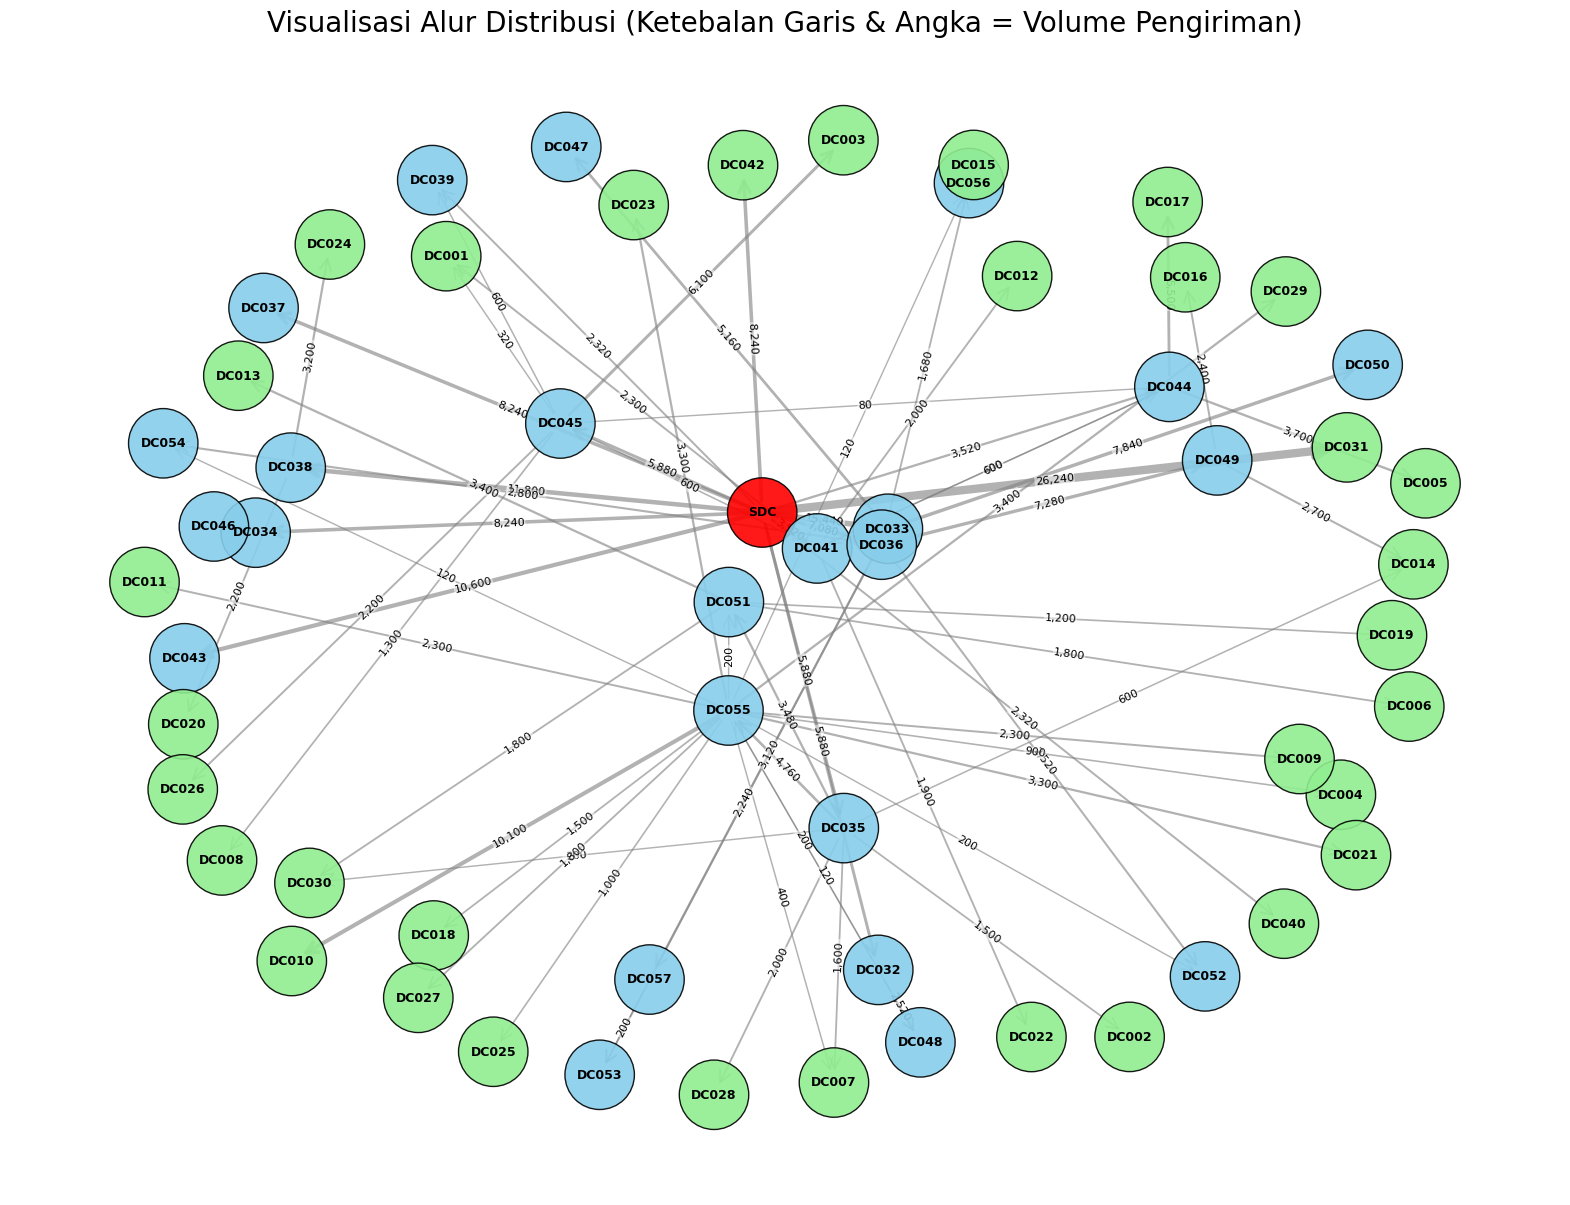

In [175]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict
# --- [TAMBAHAN] Import untuk visualisasi ---
try:
    import matplotlib.pyplot as plt
    import networkx as nx
    VISUALIZATION_ENABLED = True
except ImportError:
    VISUALIZATION_ENABLED = False


model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Diasumsikan sudah dimuat) ---
# Diperlukan DataFrame: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints
# Pastikan semua DataFrame ini sudah di-load dengan benar sebelum menjalankan kode ini.

# --- Asumsi DataFrame sudah di-load ---
# df_edges_final = pd.read_excel(...)
# df_middle_edge_list = pd.read_excel(...)
# df_resources_joined = pd.read_excel(...)
# df_demand = pd.read_excel(...)
# df_order_constraints = pd.read_excel(...)
# df_turnover = pd.read_excel(...)


vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80,
    'FUSO': 350
}

WORKING_HOURS_PER_DAY = 10
WORKING_DAYS_PER_MONTH = 24
WORKING_HOURS_PER_MONTH = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH  # 240 jam
DAYS_IN_MONTH = WORKING_DAYS_PER_MONTH

# --- [DIHAPUS] Penalti tidak lagi diperlukan karena demand wajib terpenuhi ---
# UNMET_PENALTY_PER_BOX = 1_000_000_000


# Konversi kolom numerik
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

# Paksa update volume_per_trip di df_edges_final sesuai mode_param
df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol

# Penyesuaian: Sesuaikan volume_per_trip dengan max_volume per rute
df_middle_edge_indexed = df_middle_edge_list.set_index(['origin_id', 'destination_id'])
for idx, row in df_edges_final.iterrows():
    i, j = row['source_node'], row['target_node']
    if (i, j) in df_middle_edge_indexed.index:
        route_max_volume_per_trip = df_middle_edge_indexed.loc[(i, j), 'max_volume']
        if pd.notna(route_max_volume_per_trip) and route_max_volume_per_trip > 0:
            df_edges_final.loc[idx, 'volume_per_trip'] = min(row['volume_per_trip'], route_max_volume_per_trip)

# Buat dictionary data dari DataFrame
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip) and r.volume_per_trip > 0
}

lead_time_dict_sdc = {
    ("SDC", r['target_node']): int(r['lead_time_days']) * 24
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

speed_by_mode = {'GrandMax': 40, 'Kijang': 50, 'CDE': 45, 'CDD': 45, 'FUSO': 35}
lead_time_dict_dc = {}
for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    if (i, j) in df_middle_edge_indexed.index:
        dist_km = df_middle_edge_indexed.loc[(i, j), 'distance_km']
        speed = speed_by_mode.get(m, 40)
        if pd.notna(dist_km) and speed > 0:
            lead_time_dict_dc[(i, j, m)] = int(round(dist_km / speed))

lead_time_dict = {**lead_time_dict_sdc, **lead_time_dict_dc}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4)
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

trip_limit = {}
for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    for mode in vehicle_modes:
        if mode in row and pd.notna(row[mode]):
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 999999

turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * row['Turnover Per Bulan']))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}

# --- 2. DECISION VARIABLES ---
x = {}
max_trips_possible = math.ceil(max(demand_dict.values()) / min(v for v in mode_param.values() if v > 0)) if mode_param else 1000
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    if volume_per_trip.get((i, j, m), 0) > 0:
        x[i, j, m] = model.NewIntVar(0, max_trips_possible, f"x_{i}{j}{m}")

# --- [DIHAPUS] Variabel Unmet Demand tidak lagi diperlukan ---
# unmet = { ... }

# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list)
incoming_vars = defaultdict(list)

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))

    if i.startswith("SDC") and j in order_limit:
        model.Add(var <= order_limit[j])

for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])

for j, varlist in incoming_vars.items():
    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 1_000_000_000))
    if capacity > 0:
        model.Add(sum(var * vol for var, vol in varlist) <= capacity)

# --- [PERUBAHAN] Constraint Demand: Total yang dikirim HARUS >= Demand ---
for j, demand in demand_dict.items():
    total_sent_to_j = sum(
        x.get((i, j2, m), 0) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in volume_per_trip if j2 == j
    )
    model.Add(total_sent_to_j >= demand)

# Variabel dan constraint kendaraan aktif
vehicle_used = {}
all_dc_origins = df_resources_joined['dc_id'].unique()

for i in all_dc_origins:
    for m in vehicle_modes:
        total_workload_expr = []
        for (src, j, mode), var in x.items():
            if src == i and mode == m:
                lead = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
                if lead and lead > 0:
                    total_workload_expr.append(var * (2 * lead))

        if total_workload_expr:
            available_vehicles = 0
            if m in df_resources_joined.columns:
                res = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m]
                if not res.empty:
                    available_vehicles = int(res.iloc[0])

            vehicle_var = model.NewIntVar(0, available_vehicles, f"vehicle_used_{i}_{m}")
            model.Add(sum(total_workload_expr) <= vehicle_var * WORKING_HOURS_PER_MONTH)
            vehicle_used[(i, m)] = vehicle_var

# Constraint global kendaraan per mode
vehicle_global_limit = {'GrandMax': 30, 'CDE': 102, 'CDD': 48, 'Kijang': 1, 'FUSO': 999}
for m in vehicle_modes:
    if m in vehicle_global_limit:
        mode_specific_vehicles = [var for (i, mode), var in vehicle_used.items() if mode == m]
        if mode_specific_vehicles:
            model.Add(sum(mode_specific_vehicles) <= vehicle_global_limit[m])

# --- 4. OBJECTIVE ---
# --- [PERUBAHAN] Objektif hanya minimalkan biaya trip. Penalti dihapus. ---
cost_terms = [var * cost_per_trip.get((i, j, m), 0) for (i, j, m), var in x.items()]
model.Minimize(sum(cost_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 300
solver.parameters.num_search_workers = 8
solver.parameters.log_search_progress = True

status = solver.Solve(model)

# --- 6. OUTPUT HASIL SOLUSI ---
print(f"⏱ Runtime solver: {solver.WallTime():.2f} detik")
print(f"📊 Status Solusi: {solver.StatusName(status)}")

if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
    
    # --- [PERUBAHAN] Laporan diubah untuk menampilkan Oversupply ---
    print("\n📦 Ringkasan Pemenuhan per DC (Dikirim vs. Oversupply):")
    summary_data = []
    total_oversupply_volume = 0
    
    # Hitung total volume terkirim per DC
    sent_volume_per_dc = defaultdict(int)
    for (i, j, m), var in x.items():
        sent_volume_per_dc[j] += solver.Value(var) * volume_per_trip.get((i, j, m), 0)

    for j, demand_val in demand_dict.items():
        sent_val = sent_volume_per_dc[j]
        oversupply_val = sent_val - demand_val
        total_oversupply_volume += oversupply_val
        
        summary_data.append({
            'DC': j,
            'Demand': demand_val,
            'Dikirim': sent_val,
            'Oversupply': oversupply_val,
            'Tingkat Pemenuhan (%)': f"{sent_val / demand_val * 100:.1f}%" if demand_val > 0 else "100.0%"
        })
    
    df_summary = pd.DataFrame(summary_data).sort_values(by='Oversupply', ascending=False)
    print(df_summary.to_string(index=False))

    print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
    total_cost = solver.ObjectiveValue()
    total_volume = 0
    sdc_to_dc_cost = 0
    inter_dc_cost = 0

    results = []
    for (i, j, m), var in x.items():
        trip = solver.Value(var)
        if trip > 0:
            cost = cost_per_trip.get((i, j, m), 0)
            vol = volume_per_trip.get((i, j, m), 0)
            subtotal = trip * cost
            volume_total = trip * vol
            results.append(f"{i} → {j} via {m} | trip = {trip:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
            total_volume += volume_total
            if i.startswith("SDC"):
                sdc_to_dc_cost += subtotal
            else:
                inter_dc_cost += subtotal
    
    for res in sorted(results):
        print(res)

    print("-" * 50)
    print(f"💰 Total Biaya Distribusi (berdasarkan cost_per_trip): Rp {int(total_cost):,}")
    print("-" * 50)
    print(f" 💸 Biaya SDC ke DC: Rp {sdc_to_dc_cost:,}")
    print(f" 💸 Biaya Antar DC: Rp {inter_dc_cost:,}")
    print(f"📦 Total Volume Dikirim: {total_volume:,} box")
    print(f"📈 Total Volume Oversupply: {total_oversupply_volume:,} box")


    print("\n📊 Total Kendaraan Aktif per Mode (Global):")
    for m in vehicle_modes:
        total = sum(solver.Value(vehicle_used[(i, mode)])
                    for (i, mode) in vehicle_used if mode == m)
        print(f"{m}: {total} / {vehicle_global_limit.get(m, 'N/A')} kendaraan")

    # --- [TAMBAHAN] Perhitungan Rincian Biaya Antar DC dan Supir ---
    print("\n" + "="*60)
    print("ANALISIS BIAYA BERDASARKAN UTILISASI ARMADA (ANTAR DC)")
    print("="*60)

    FUEL_COST_PER_DAY = 200_000
    
    # 1. Hitung total jam kerja untuk setiap armada antar-DC
    vehicle_workload = defaultdict(int)
    for (i, j, m), var in x.items():
        if not i.startswith("SDC"): # Hanya untuk rute antar-DC
            trip = solver.Value(var)
            if trip > 0:
                lead = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
                if lead and lead > 0:
                     vehicle_workload[(i,m)] += trip * (2 * lead) # round trip
    
    # 2. Hitung biaya berdasarkan utilisasi
    total_fixed_cost = 0
    total_fuel_cost = 0
    total_driver_cost = 0
    inter_dc_cost_new = 0

    # Biaya Tetap (Sewa/Gaji Pokok) & Biaya Supir
    print("\n--- Biaya Tetap & Supir per Armada ---")
    for (i, m), total_workload in vehicle_workload.items():
        if total_workload > 0:
            n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
            
            # Ambil fixed cost dari cost_per_trip (asumsi)
            # Cari satu trip valid untuk mendapatkan cost
            fixed_cost_per_vehicle = next((cost for (src, _, mode), cost in cost_per_trip.items() if src == i and mode == m), 0)
            
            fixed_component = n_kendaraan * fixed_cost_per_vehicle
            total_fixed_cost += fixed_component
            
            # Hitung biaya supir
            n_supir = 2 * n_kendaraan + 2 # Asumsi 2 supir per kendaraan + 2 cadangan
            driver_cost_per_person = 0
            if 'Driver Cost' in df_resources_joined.columns:
                 res = df_resources_joined.loc[df_resources_joined['dc_id'] == i, 'Driver Cost']
                 if not res.empty:
                     driver_cost_per_person = res.iloc[0]

            driver_component = n_supir * driver_cost_per_person
            total_driver_cost += driver_component

            print(f"🚐 Armada {i} - {m}:")
            print(f"  - Jam Kerja: {total_workload} jam -> Kendaraan Aktif: {n_kendaraan}")
            print(f"  - Biaya Tetap: {n_kendaraan} x Rp {fixed_cost_per_vehicle:,} = Rp {fixed_component:,}")
            print(f"  - Biaya Supir: {n_supir} supir x Rp {driver_cost_per_person:,} = Rp {driver_component:,}")


    # Biaya Variabel (BBM)
    print("\n--- Biaya Variabel (BBM) per Trip ---")
    for (i, j, m), var in x.items():
        if not i.startswith("SDC"):
            trip = solver.Value(var)
            if trip > 0:
                lead = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
                if lead and lead > 0:
                    duration_in_days = math.ceil((2 * lead) / 24)
                    fuel_component = trip * duration_in_days * FUEL_COST_PER_DAY
                    total_fuel_cost += fuel_component
                    print(f"  ⛽ {i} -> {j} ({m}): {trip} trip x {duration_in_days} hari x Rp {FUEL_COST_PER_DAY:,} = Rp {fuel_component:,}")

    inter_dc_cost_new = total_fixed_cost + total_fuel_cost
    grand_total_cost = inter_dc_cost_new + total_driver_cost

    print("\n" + "-"*60)
    print("REKAPITULASI BIAYA KESELURUHAN")
    print("-"*60)
    print(f"💸 Biaya Antar DC (Baru): Rp {int(inter_dc_cost_new):,}")
    print(f"  ├── Biaya Tetap Armada: Rp {int(total_fixed_cost):,}")
    print(f"  └── Biaya Bahan Bakar : Rp {int(total_fuel_cost):,}")
    print(f"🚚 Biaya Supir         : Rp {int(total_driver_cost):,}")
    print(f"💰 TOTAL KESELURUHAN   : Rp {int(grand_total_cost):,}")
    print("="*60)


else:
    print(f"❌ Solusi tidak ditemukan dengan status: {solver.StatusName(status)}")
    print("Ini berarti bahkan dengan mengizinkan oversupply, sumber daya Anda tetap tidak cukup.")
    print("Kemungkinan penyebabnya adalah batasan keras seperti kapasitas gudang, limit kendaraan, atau jam kerja.")

# --- 7. VISUALISASI RUTE PENGIRIMAN ---
# Bagian ini membuat visualisasi graf dari rute yang aktif dalam solusi.
# Diperlukan library matplotlib dan networkx.
# Anda mungkin perlu menginstalnya terlebih dahulu: pip install matplotlib networkx
if VISUALIZATION_ENABLED and status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("\n" + "="*60)
    print("VISUALISASI RUTE PENGIRIMAN")
    print("="*60)

    # Buat graph baru
    G = nx.DiGraph()
    
    # Kumpulkan data rute aktif dan total volumenya
    active_routes = defaultdict(int)
    for (i, j, m), var in x.items():
        trip_count = solver.Value(var)
        if trip_count > 0:
            vol = volume_per_trip.get((i, j, m), 0)
            total_volume_on_route = trip_count * vol
            active_routes[(i, j)] += total_volume_on_route
            
    # Tambahkan edge ke graph dengan bobot (total volume)
    for (i, j), total_volume in active_routes.items():
        G.add_edge(i, j, weight=total_volume)

    if G.number_of_nodes() > 0:
        # Tentukan posisi node untuk visualisasi
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42) 

        # Tentukan warna node
        node_colors = []
        for node in G.nodes():
            if node.startswith("SDC"):
                node_colors.append('red')
            elif node in all_dc_origins: # DC yang juga menjadi sumber
                 node_colors.append('skyblue')
            else: # DC penerima murni
                node_colors.append('lightgreen')

        plt.figure(figsize=(20, 15))
        
        # Gambar graph
        nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=node_colors, alpha=0.9,
                               edgecolors='black')
        
        # Gambar edge dengan ketebalan berdasarkan volume
        # Normalisasi bobot untuk ketebalan garis yang lebih baik
        all_weights = [G[u][v]['weight'] for u, v in G.edges()]
        max_weight = max(all_weights) if all_weights else 1
        edge_widths = [1 + 5 * (G[u][v]['weight'] / max_weight) for u, v in G.edges()]
        
        nx.draw_networkx_edges(G, pos,
                               width=edge_widths,
                               alpha=0.6,
                               edge_color='gray',
                               arrowstyle='->',
                               arrowsize=20)

        # Tambahkan label nama node
        nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
        
        # Tambahkan label pada edge (total volume)
        edge_labels = nx.get_edge_attributes(G, 'weight')
        # Format label agar lebih mudah dibaca
        formatted_edge_labels = {k: f"{v:,.0f}" for k, v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, 
                                     font_color='black', font_size=8,
                                     bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5))
        
        plt.title("Visualisasi Alur Distribusi (Ketebalan Garis & Angka = Volume Pengiriman)", size=20)
        plt.axis('off') # Sembunyikan sumbu
        plt.show()
    else:
        print("Tidak ada rute aktif untuk divisualisasikan.")

elif not VISUALIZATION_ENABLED:
    print("\n[Peringatan] Library 'matplotlib' atau 'networkx' tidak terinstal.")
    print("Visualisasi rute dilewati. Silakan instal dengan 'pip install matplotlib networkx'")

In [178]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # Dictionary untuk menyimpan variabel unmet demand

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Diasumsikan sudah dimuat) ---
# Diperlukan DataFrame: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints
# Pastikan semua DataFrame ini sudah di-load dengan benar sebelum menjalankan kode ini.

vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80,
    'FUSO': 350 # Pastikan FUSO ada jika digunakan
}
PENALTY_RATE = 100_000_000_000 # Penalti untuk setiap unit demand yang tidak terpenuhi (untuk motivasi solver)

WORKING_HOURS_PER_DAY = 10
WORKING_DAYS_PER_MONTH = 24
TOTAL_WORKING_HOURS = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH  # 240 jam
DAYS_IN_MONTH = WORKING_DAYS_PER_MONTH # Definisikan untuk konsistensi

# Konversi kolom numerik
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()  # Buang spasi ekstra
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol

# --- Penyesuaian: Sesuaikan volume_per_trip dengan max_volume per rute (jika max_volume adalah batas per trip) ---
df_middle_edge_indexed = df_middle_edge_list.set_index(['origin_id', 'destination_id'])

for idx, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    # Cek apakah rute (i, j) ada di df_middle_edge_indexed dan punya max_volume
    if (i, j) in df_middle_edge_indexed.index:
        route_max_volume_per_trip = df_middle_edge_indexed.loc[(i, j), 'max_volume']
        if pd.notna(route_max_volume_per_trip) and route_max_volume_per_trip > 0:
            # Volume efektif per trip adalah minimum dari volume kendaraan atau batas rute
            df_edges_final.loc[idx, 'volume_per_trip'] = min(row['volume_per_trip'], route_max_volume_per_trip)
        # Jika route_max_volume_per_trip NaN atau 0, kita biarkan volume_per_trip sesuai mode_param

# Buat dictionary volume_per_trip setelah modifikasi df_edges_final
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

# Dictionary lead time dari SDC ke DC tujuan
lead_time_dict_sdc = {
    ("SDC", r['target_node']): int(r['lead_time_days']) * 24 # Konversi ke jam
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

# Mapping kecepatan kendaraan
speed_by_mode = {
    'GrandMax': 40,
    'Kijang': 50,
    'CDE': 45,
    'CDD': 45,
    'FUSO': 35
}

# Buat dictionary lead_time_dict_dc berdasarkan rute antar DC dan mode
lead_time_dict_dc = {}
# df_middle_edge tetap merujuk ke df_middle_edge_list seperti permintaan user
df_middle_edge = df_middle_edge_list.copy() 

for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    if (i, j) in df_middle_edge_indexed.index: # Gunakan indexed df_middle_edge_list
        dist_km = df_middle_edge_indexed.loc[(i, j), 'distance_km']
        speed = speed_by_mode.get(m, 40)  # Default 40 km/jam kalau mode gak dikenal
        if pd.notna(dist_km) and speed > 0:
            lead_time = int(round(dist_km / speed)) # Hasil dalam jam (km / (km/jam))
            lead_time_dict_dc[(i, j, m)] = lead_time

# Gabungkan kedua dictionary lead time
lead_time_dict = {**lead_time_dict_sdc, **lead_time_dict_dc}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

# volume_cap_dict dan constraint terkait DIHAPUS karena max_volume sekarang diinterpretasikan per trip
# dan sudah disesuaikan ke volume_per_trip di awal.

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4) # Diasumsikan 4 minggu dalam sebulan
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

trip_limit = {}
for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    for mode in vehicle_modes:
        if mode in row and pd.notna(row[mode]):
            # trip_limit adalah jumlah total trip bulanan yang bisa dilakukan oleh armada di DC tersebut
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 999999  # Nilai sangat besar agar tidak membatasi

# Jika df_turnover tidak tersedia, buat dummy
if 'df_turnover' not in locals():
    unique_dc_ids = df_demand['DC ID'].unique()
    df_turnover = pd.DataFrame({
        'DC ID': unique_dc_ids,
        'Capacity': [100000] * len(unique_dc_ids), # Kapasitas default tinggi
        'Turnover Per Bulan': [1] * len(unique_dc_ids) # Turnover default 1
    })

turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * (row['Turnover Per Bulan'] + 1)))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}

# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1) # Default 1 untuk menghindari pembagian dengan nol
    dem = demand_dict.get(j, 0) # Default 0 jika DC tidak ada di demand_dict
    # Batas atas untuk trip bisa lebih realistis: total demand tertinggi dibagi volume terkecil
    max_trips_possible = math.ceil(max(demand_dict.values()) / min(mode_param.values())) if mode_param else 1_000_000
    x[i, j, m] = model.NewIntVar(0, max_trips_possible, f"x_{i}{j}{m}")


# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list) # Untuk mengumpulkan variabel trip per (DC asal, mode)
incoming_vars = defaultdict(list) # Untuk mengumpulkan variabel trip masuk per DC tujuan

# Menggunakan df_middle_edge_list untuk definisi rute valid
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge_list.origin_id, df_middle_edge_list.destination_id))

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    
    # Hanya tambahkan constraint lead time jika BUKAN dari SDC
    # Prioritaskan lead time spesifik per mode, lalu lead time rute umum
    lead = lead_time_dict.get((i, j, m))
    if lead is None:
        lead = lead_time_dict.get((i, j)) # Jika tidak ada mode spesifik, coba rute umum

    if lead is not None and not i.startswith("SDC") and lead > 0:
        # Cari jumlah kendaraan di depot i untuk mode m
        n_vehicle_per_dc_mode = 0
        if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
            temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
            if isinstance(temp_n_vehicle, pd.Series): # Handle jika .squeeze() mengembalikan Series kosong/multi-nilai
                n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
            else:
                n_vehicle_per_dc_mode = temp_n_vehicle
            
            if pd.isna(n_vehicle_per_dc_mode):
                n_vehicle_per_dc_mode = 0
            n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode) # Pastikan integer

        if n_vehicle_per_dc_mode > 0:
            total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
            trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead) # 2 * lead untuk round trip

            max_trip_by_lead_time = n_vehicle_per_dc_mode * trips_per_vehicle_per_month
            model.Add(var <= max_trip_by_lead_time)
        else:
            # Jika tidak ada kendaraan untuk mode ini di DC sumber, maka trip harus 0
            # model.Add(var == 0)
            pass
    elif lead == 0 and not i.startswith("SDC"): # Jika lead time 0 dan bukan SDC, batasi trip jadi 0 (tidak realistis)
        model.Add(var == 0)

    # --- Constraint: Valid Route ---
    # Memastikan hanya trip pada rute yang valid yang dipertimbangkan
    if (i, j) not in valid_routes:
        model.Add(var == 0)

    # --- Constraint: SDC ke DC order constraint mingguan (per MODA) ---
    # Ini memastikan setiap MODA dari SDC ke DC tujuan memiliki batas trip sendiri
    if i.startswith("SDC") and j in order_limit:
        # Asumsi: order_limit[j] adalah batas trip untuk setiap moda ke DC tersebut dari SDC
        model.Add(var <= order_limit[j])


# --- Constraint: total trip per (i, mode) ---
# Membatasi jumlah total trip yang bisa dilakukan oleh armada tertentu dari DC asal
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])


# --- Constraint: total volume masuk per DC (Kapasitas Gudang Tujuan) ---
# Memastikan total volume yang masuk ke DC tujuan tidak melebihi kapasitas gudang
for j, varlist in incoming_vars.items():
    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000)) # Default tinggi jika tidak ada
    if capacity > 0: # Pastikan kapasitas positif untuk menghindari masalah
        model.Add(sum(var * vol for var, vol in varlist) <= capacity)


# --- TAMBAHAN: Variabel kendaraan aktif per DC & Mode ---
vehicle_used = {}

for i in df_resources_joined['dc_id'].unique():
    for m in vehicle_modes:
        relevant_trips = [(j, mode) for (src, j, mode) in x if src == i and mode == m]
        if not relevant_trips:
            continue

        total_workload_expr = []
        for j, mode in relevant_trips:
            var = x[i, j, m]
            lead = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j)) or 12  # default 12 jam
            total_workload_expr.append(var * (2 * lead))  # round trip

        vehicle_var = model.NewIntVar(0, 999, f"vehicle_used_{i}_{m}")
        model.Add(vehicle_var * WORKING_HOURS_PER_MONTH >= sum(total_workload_expr))
        vehicle_used[(i, m)] = vehicle_var

# --- Constraint global kendaraan per mode ---
vehicle_global_limit = {
    'GrandMax': 30,
    'CDE': 102,
    'CDD': 48,
    'Kijang': 1,
}

for m in vehicle_modes:
    model.Add(
        sum(vehicle_used[(i, m)] for i in df_resources_joined['dc_id'].unique() if (i, m) in vehicle_used)
        <= vehicle_global_limit.get(m, 0)
    )

# --- 4. OBJECTIVE ---
cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]
penalty_terms = []
sent_volume_var = {}

for j, demand in demand_dict.items():
    sent = model.NewIntVar(0, demand, f"sent_{j}")
    # Volume yang dikirim ke DC j
    model.Add(sent == sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
                        for (i, j2, m) in x if j2 == j))

    unmet_var = model.NewIntVar(0, demand, f"unmet_{j}")
    model.Add(unmet_var <= 0)
    model.AddMaxEquality(unmet_var, [0, demand - sent])  # ✅ Fix unmet jadi max(0, demand - sent)

        
    # Tambahkan penalti untuk setiap unmet demand
    penalty_terms.append(unmet_var * PENALTY_RATE)
    
    unmet[j] = unmet_var  # Simpan variabel unmet untuk laporan nanti
    sent_volume_var[j] = sent  # Simpan total volume yang berhasil dikirim

# Fungsi objektif: Minimalkan (biaya distribusi + penalti unmet demand)
model.Minimize(sum(cost_terms) + sum(penalty_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 180 # Batas waktu eksekusi solver
solver.parameters.num_search_workers = 4  # Mengaktifkan multi-threading
solver.parameters.linearization_level = 2  # Level linearisasi (bisa membantu kinerja)

status = solver.Solve(model) # Jalankan solver

print(f"⏱ Runtime solver: {solver.WallTime():.2f} detik")

print("\n📦 Summary per DC (Sent vs Unmet):")
for j in sent_volume_var:
    print(f"{j}: sent = {solver.Value(sent_volume_var[j]):,} | unmet = {solver.Value(unmet[j]):,}")


# --- 6. OUTPUT HASIL SOLUSI ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi atau tidak mencapai optimal dalam batas waktu.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0
sdc_to_dc_cost = 0 # Inisialisasi biaya SDC-DC
inter_dc_cost = 0  # Inisialisasi biaya Antar-DC


for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        
        # Peringatan jika ada trip tanpa biaya atau volume (biasanya berarti ada masalah data)
        if cost == 0 or vol == 0:
            print(f"❗Trip tanpa biaya/volume: {i} → {j} via {m} | cost = {cost}, vol = {vol}")

        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total

        # --- Tambahan: Klasifikasi Biaya ---
        if i.startswith("SDC"):
            sdc_to_dc_cost += subtotal
        else:
            inter_dc_cost += subtotal
        
        # Peringatan untuk trip yang sangat mahal per box
        if trip > 0 and vol > 0:
            cost_per_box = cost / vol
            if cost_per_box > 1_000_000: # Batas peringatan, sesuaikan
                print(f"⚠ TRIP MAHAL: {i} → {j} via {m} = Rp {cost_per_box:,.0f}/box")


print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"  💸 Biaya SDC ke DC: Rp {sdc_to_dc_cost:,}") # Cetak rincian
print(f"  💸 Biaya Antar DC: Rp {inter_dc_cost:,}")   # Cetak rincian
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

print("\n💸 Trip dengan Cost per Box Tertinggi:")
trip_costs = []

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            trip_costs.append((cost_per_box, i, j, m, cost, vol, trip))

trip_costs.sort(reverse=True)  # Urutkan dari yang paling mahal per box
for cpb, i, j, m, c, v, t in trip_costs[:10]:  # Tampilkan top 10
    print(f"🔥 Rp {cpb:,.0f}/box → {i} → {j} via {m} | trip = {t}, cost/trip = Rp {c:,}, vol/trip = {v}")


# Hitung total unmet demand dan penalti
total_unmet = sum(solver.Value(unmet[j]) for j in demand_dict)
total_penalty = total_unmet * PENALTY_RATE

# Bagian bonus keanekaragaman dihapus dari output
print(f"🚫 Total Unmet Demand: {total_unmet:,} box")
print(f"💣 Total Penalti: Rp {total_penalty:,.0f}")
print(f"🧾 Biaya Total Akhir (Distribusi + Denda): Rp {total_cost + total_penalty:,.0f}")


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug_data = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    # Bagian modes_used_for_dc juga dihapus karena variabel y tidak lagi ada
    # modes_used_for_dc = [m for m in vehicle_modes if (j,m) in y and solver.Value(y[j,m]) == 1]

    debug_data.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim,
        'Moda Digunakan': "N/A (Diversity Bonus Disabled)" # Ganti dengan pesan ini
    })

df_debug = pd.DataFrame(debug_data).sort_values(by='Unmet', ascending=False)

# Tampilkan 30 DC dengan unmet demand terbesar
print(df_debug.head(30).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # Ambil 5 DC teratas untuk analisis detail
    print(f"\n[DC: {j}]")
    
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips_val = solver.Value(x[i, j, m])
        
        # Informasi Batas Trip Armada
        if i.startswith("SDC"):
            max_trip_limit_text = "∞ (Unlimited)"
        else:
            max_trip_limit = trip_limit.get((i, m), 0)
            max_trip_limit_text = f"{max_trip_limit:,}"

        # Informasi Batas Trip dari Lead Time
        lead = lead_time_dict.get((i, j, m))
        if lead is None:
            lead = lead_time_dict.get((i, j))

        max_trip_lead_text = '–'
        if lead is not None and lead > 0 and not i.startswith("SDC"):
            n_vehicle_per_dc_mode = 0
            if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
                temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
                if isinstance(temp_n_vehicle, pd.Series):
                    n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
                else:
                    n_vehicle_per_dc_mode = temp_n_vehicle
                if pd.isna(n_vehicle_per_dc_mode):
                    n_vehicle_per_dc_mode = 0
                n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode)

            if n_vehicle_per_dc_mode > 0:
                total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
                trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead)
                max_trip_lead_text = f"{n_vehicle_per_dc_mode * trips_per_vehicle_per_month:,}"
            else:
                max_trip_lead_text = "0 (No vehicles)"
        elif i.startswith("SDC"): # Khusus SDC, batasan order_wk diterapkan per moda
            max_trip_lead_text = f"Controlled by order_wk ({order_limit.get(j, 'N/A')})"


        route_valid = (i, j) in valid_routes
        # Max_volume_per_trip dari data rute mempengaruhi 'vol' (volume_per_trip) di awal.
        # Ini adalah nilai asli dari df_middle_edge_list
        route_max_vol_per_trip_from_data = df_middle_edge_indexed.loc[(i,j), 'max_volume'] if (i,j) in df_middle_edge_indexed.index and pd.notna(df_middle_edge_indexed.loc[(i,j), 'max_volume']) else "No specific limit"

        # print(f"- {i} → {j} via {m}:")
        # print(f"  ✔ Rute valid? {route_valid}")
        # print(f"  🚚 Trip yang digunakan: {trips_val:,}")
        # print(f"  📦 Volume/trip (setelah penyesuaian): {vol:,}")
        # print(f"  🛣 Max_volume_per_trip dari data rute: {route_max_vol_per_trip_from_data}")
        # print(f"  💼 Batas trip dari armada: {max_trip_limit_text}")
        # print(f"  ⏱ Batas trip dari lead time: {max_trip_lead_text}")

print("\n📨 Detail Rute Masuk ke DC033 (Contoh):")
for (i, j, m) in x:
    if j == "DC033": # Ganti dengan DC yang ingin Anda periksa detailnya
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        print(f"{i} → {j} via {m}: trips = {trips}, total vol = {trips * vol:,} | vol/trip = {vol}")

from math import ceil

# --- Biaya Antar DC Berdasarkan Utilisasi Armada ---
print("\n🚛 Biaya Antar DC (Baru - Berdasarkan Utilisasi Armada):\n" + "-" * 60)

inter_dc_cost_new = 0
vehicle_workload = defaultdict(int)  # key: (i, m), value: total jam kerja (trip × durasi)
vehicle_fixed_cost = defaultdict(int)  # key: (i, m), value: fixed cost per kendaraan

# Durasi kerja bulanan
WORKING_HOURS_PER_MONTH = 240
FUEL_COST_PER_DAY = 200_000

# Bangun fixed cost dari df_edges_final
for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    if not i.startswith("SDC"):
        vehicle_fixed_cost[(i, m)] = int(row['cost_per_trip'])  # cost_per_trip = fixed cost per kendaraan

# Estimasi total jam kerja kendaraan (per DC asal & mode)
for (i, j, m), var in x.items():
    if i.startswith("SDC"):
        continue  # lewati, ini ditangani di bagian SDC
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue
        duration_per_trip = 2 * lead_time  # round trip
        vehicle_workload[(i, m)] += trip * duration_per_trip



inter_dc_cost_new = 0
total_fixed_cost = 0
total_fuel_cost = 0



# --- 1. FIXED COST berdasarkan kendaraan aktif per DC & mode ---
for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    fixed_cost = vehicle_fixed_cost.get((i, m), 0)
    fixed_component = n_kendaraan * fixed_cost
    total_fixed_cost += fixed_component  # ✅ track fixed cost
    inter_dc_cost_new += fixed_component

    print(f"🚐 {i} - {m} | Jam total: {total_workload}, Kendaraan aktif: {n_kendaraan}, Fixed: Rp {fixed_component:,}")

# --- 2. VARIABLE COST (bensin) berdasarkan trip ---
for (i, j, m), var in x.items():
    if i.startswith("SDC"):  # Skip jalur dari pabrik
        continue
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue

        duration_per_trip = 2 * lead_time
        duration_in_days = math.ceil(duration_per_trip / 24)
        fuel_component = trip * duration_in_days * FUEL_COST_PER_DAY

        total_fuel_cost += fuel_component  # ✅ track fuel cost
        inter_dc_cost_new += fuel_component

        print(f"⛽ {i} → {j} via {m} | trips: {trip}, durasi: {duration_in_days} hari, fuel cost: Rp {fuel_component:,}")

# --- 3. REKAP TOTAL COST ---
print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"   └── Fixed Cost: Rp {total_fixed_cost:,}")
print(f"   └── Fuel Cost:  Rp {total_fuel_cost:,}")



# --- 3. DRIVER COST ---
total_driver_cost = 0

for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    n_supir = 2 * n_kendaraan + 2  # 2 per kendaraan + 2 supir tambahan

    # Ambil biaya driver per (DC, mode)
    driver_cost = df_resources_joined[
        (df_resources_joined['dc_id'] == i)
    ]['Driver Cost'].values

    if len(driver_cost) == 0:
        print(f"[WARNING] Tidak ada data driver cost untuk {i}-{m}, diasumsikan Rp 0")
        driver_cost = [0]

    cost_per_driver = driver_cost[0]
    total_driver_component = n_supir * cost_per_driver
    total_driver_cost += total_driver_component

    print(f"🧍 {i} - {m} | Kendaraan aktif: {n_kendaraan}, Supir: {n_supir}, "
          f"Cost/Driver: Rp {cost_per_driver:,}, Total: Rp {total_driver_component:,}")

# --- 4. TOTAL BIAYA (DC + DRIVER) ---
grand_total_cost = inter_dc_cost_new + total_driver_cost

print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"🚚 Biaya Supir         : Rp {total_driver_cost:,}")
print(f"💰 TOTAL KESELURUHAN   : Rp {grand_total_cost:,}")

print("\n📊 Total Kendaraan Aktif per Mode (Global):")
for m in vehicle_modes:
    total = sum(solver.Value(vehicle_used[(i, m)])
                for i in df_resources_joined['dc_id'].unique()
                if (i, m) in vehicle_used)
    print(f"{m}: {total} kendaraan")

for dc in df_debug.head(10)['DC']:
    print(f"🛑 {dc} → order_limit: {order_limit.get(dc, 'N/A')}")

# Misal kamu mau debug DC016 (atau DC manapun yang masih unmet)
dc_target = 'DC016'

print(f"\n🔎 Debug semua rute masuk ke {dc_target}")
for (i, j, m) in x:
    if j == dc_target:
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        cost = cost_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            print(f"{i} → {j} via {m}: trip = {trips}, vol/trip = {vol}, cost/trip = Rp {cost:,}, cost/box = Rp {cost_per_box:,.0f}")

⏱ Runtime solver: 0.00 detik

📦 Summary per DC (Sent vs Unmet):
DC001: sent = 188,978,561,144 | unmet = 489,626,271,776
DC002: sent = 511,101,108,335 | unmet = 450,971,566,112
DC003: sent = 137,438,953,582 | unmet = 438,086,664,292
DC004: sent = 433,791,696,991 | unmet = 442,381,631,588
DC005: sent = 493,921,239,141 | unmet = 438,086,664,287
DC006: sent = 472,446,402,665 | unmet = 463,856,468,065
DC007: sent = 450,971,566,126 | unmet = 433,791,697,012
DC008: sent = 489,626,271,858 | unmet = 511,101,108,335
DC009: sent = 171,798,691,955 | unmet = 249,108,103,209
DC010: sent = 137,438,953,482 | unmet = 137,438,953,504
DC011: sent = 450,971,566,112 | unmet = 137,438,953,516
DC012: sent = 188,978,561,130 | unmet = 468,151,435,296
DC013: sent = 261,993,005,088 | unmet = 489,626,271,776
DC014: sent = 511,101,108,335 | unmet = 167,503,724,635
DC015: sent = 476,741,369,971 | unmet = 489,626,271,861
DC016: sent = 433,791,696,995 | unmet = 472,446,402,655
DC017: sent = 429,496,729,711 | unmet = 

In [159]:
# --- 0. IMPORTS & MODEL SETUP ---
from ortools.sat.python import cp_model
import pandas as pd
import math
from collections import defaultdict

unmet = {}  # Dictionary untuk menyimpan variabel unmet demand

model = cp_model.CpModel()

# --- 1. DATA PREPARATION (Diasumsikan sudah dimuat) ---
# Diperlukan DataFrame: df_edges_final, df_middle_edge_list, df_resources_joined, df_demand, df_order_constraints
# Pastikan semua DataFrame ini sudah di-load dengan benar sebelum menjalankan kode ini.

vehicle_modes = ['CDD', 'CDE', 'GrandMax', 'FUSO', 'Kijang']
mode_param = {
    'CDD': 280,
    'CDE': 200,
    'GrandMax': 120,
    'Kijang': 80,
    'FUSO': 350 # Pastikan FUSO ada jika digunakan
}
PENALTY_RATE = 100_000_000_000 # Penalti untuk setiap unit demand yang tidak terpenuhi (untuk motivasi solver)

WORKING_HOURS_PER_DAY = 10
WORKING_DAYS_PER_MONTH = 24
TOTAL_WORKING_HOURS = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH  # 240 jam
DAYS_IN_MONTH = WORKING_DAYS_PER_MONTH # Definisikan untuk konsistensi

# Konversi kolom numerik
for col in ['volume_per_trip', 'cost_per_trip']:
    df_edges_final[col] = pd.to_numeric(df_edges_final[col], errors='coerce')
df_middle_edge_list['max_volume'] = pd.to_numeric(df_middle_edge_list['max_volume'], errors='coerce')

# --- Paksa update volume_per_trip di df_edges_final sesuai mode_param ---
df_edges_final['mode_type'] = df_edges_final['mode_type'].str.strip()  # Buang spasi ekstra
for mode, vol in mode_param.items():
    df_edges_final.loc[df_edges_final['mode_type'] == mode, 'volume_per_trip'] = vol

# --- Penyesuaian: Sesuaikan volume_per_trip dengan max_volume per rute (jika max_volume adalah batas per trip) ---
# Membuat indeks untuk df_middle_edge_list agar pencarian lebih efisien
df_middle_edge_indexed = df_middle_edge_list.set_index(['origin_id', 'destination_id'])

for idx, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    # Cek apakah rute (i, j) ada di df_middle_edge_indexed dan punya max_volume
    if (i, j) in df_middle_edge_indexed.index:
        route_max_volume_per_trip = df_middle_edge_indexed.loc[(i, j), 'max_volume']
        if pd.notna(route_max_volume_per_trip) and route_max_volume_per_trip > 0:
            # Volume efektif per trip adalah minimum dari volume kendaraan atau batas rute
            df_edges_final.loc[idx, 'volume_per_trip'] = min(row['volume_per_trip'], route_max_volume_per_trip)
        # Jika route_max_volume_per_trip NaN atau 0, kita biarkan volume_per_trip sesuai mode_param
        # Ini berarti rute tidak memiliki batasan volume per trip yang lebih rendah
        # dari kapasitas kendaraan standar.

# Buat dictionary volume_per_trip setelah modifikasi df_edges_final
volume_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.volume_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.volume_per_trip)
}

# Dictionary lead time dari SDC ke DC tujuan
lead_time_dict_sdc = {
    ("SDC", r['target_node']): int(r['lead_time_days']) * 24 # Konversi ke jam
    for _, r in df_order_constraints.iterrows() if pd.notna(r['lead_time_days'])
}

# Mapping kecepatan kendaraan
speed_by_mode = {
    'GrandMax': 40,
    'Kijang': 50,
    'CDE': 45,
    'CDD': 45,
    'FUSO': 35
}

# Buat dictionary lead_time_dict_dc berdasarkan rute antar DC dan mode
lead_time_dict_dc = {}
# df_middle_edge tetap merujuk ke df_middle_edge_list seperti permintaan user
df_middle_edge = df_middle_edge_list.copy() 

for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    
    if (i, j) in df_middle_edge_indexed.index: # Gunakan indexed df_middle_edge_list
        dist_km = df_middle_edge_indexed.loc[(i, j), 'distance_km']
        speed = speed_by_mode.get(m, 40)  # Default 40 km/jam kalau mode gak dikenal
        if pd.notna(dist_km) and speed > 0:
            lead_time = int(round(dist_km / speed)) # Hasil dalam jam (km / (km/jam))
            lead_time_dict_dc[(i, j, m)] = lead_time

# Gabungkan kedua dictionary lead time
lead_time_dict = {**lead_time_dict_sdc, **lead_time_dict_dc}

cost_per_trip = {
    (r.source_node, r.target_node, r.mode_type): int(round(r.cost_per_trip))
    for _, r in df_edges_final.iterrows() if pd.notna(r.cost_per_trip)
}

# volume_cap_dict dan constraint terkait DIHAPUS karena max_volume sekarang diinterpretasikan per trip
# dan sudah disesuaikan ke volume_per_trip di awal.

demand_dict = {
    r['DC ID']: int(round(r['Total Demand (box)']))
    for _, r in df_demand.iterrows() if pd.notna(r['Total Demand (box)'])
}

capacity_dict = {
    r['dc_id']: int(round(r['Capacity']))
    for _, r in df_resources_joined.iterrows() if pd.notna(r['Capacity'])
}

order_limit = {
    r['target_node']: int(r['order_wk'] * 4) # Diasumsikan 4 minggu dalam sebulan
    for _, r in df_order_constraints.iterrows() if pd.notna(r['order_wk'])
}

trip_limit = {}
for _, row in df_resources_joined.iterrows():
    dc = row['dc_id']
    for mode in vehicle_modes:
        if mode in row and pd.notna(row[mode]):
            # trip_limit adalah jumlah total trip bulanan yang bisa dilakukan oleh armada di DC tersebut
            trip_limit[(dc, mode)] = int(row[mode] * DAYS_IN_MONTH)

# --- Tambahan: Anggap SDC punya kendaraan unlimited ---
for mode in vehicle_modes:
    trip_limit[("SDC", mode)] = 999999  # Nilai sangat besar agar tidak membatasi

# Jika df_turnover tidak tersedia, buat dummy
if 'df_turnover' not in locals():
    unique_dc_ids = df_demand['DC ID'].unique()
    df_turnover = pd.DataFrame({
        'DC ID': unique_dc_ids,
        'Capacity': [100000] * len(unique_dc_ids), # Kapasitas default tinggi
        'Turnover Per Bulan': [1] * len(unique_dc_ids) # Turnover default 1
    })

turnover_capacity_dict = {
    row['DC ID']: int(round(row['Capacity'] * row['Turnover Per Bulan']))
    for _, row in df_turnover.iterrows()
    if pd.notna(row['Capacity']) and pd.notna(row['Turnover Per Bulan'])
}


# --- 2. DECISION VARIABLES ---
x = {}
for i, j, m in df_edges_final[['source_node', 'target_node', 'mode_type']].itertuples(index=False, name=None):
    vol = volume_per_trip.get((i, j, m), 1) # Default 1 untuk menghindari pembagian dengan nol
    dem = demand_dict.get(j, 0) # Default 0 jika DC tidak ada di demand_dict
    # Batas atas untuk trip bisa lebih realistis: total demand tertinggi dibagi volume terkecil
    # Ini untuk mencegah variabel menjadi terlalu besar dan memperlambat solver
    max_trips_possible = math.ceil(max(demand_dict.values()) / min(mode_param.values())) if mode_param else 1_000_000
    x[i, j, m] = model.NewIntVar(0, max_trips_possible, f"x_{i}{j}{m}")


# --- 3. CONSTRAINTS ---
trip_vars = defaultdict(list) # Untuk mengumpulkan variabel trip per (DC asal, mode)
incoming_vars = defaultdict(list) # Untuk mengumpulkan variabel trip masuk per DC tujuan

# Menggunakan df_middle_edge_list untuk definisi rute valid
valid_routes = set(zip(df_edges_final.source_node, df_edges_final.target_node)) | \
               set(zip(df_middle_edge_list.origin_id, df_middle_edge_list.destination_id))

for (i, j, m), var in x.items():
    vol = volume_per_trip.get((i, j, m), 0)
    trip_vars[(i, m)].append(var)
    incoming_vars[j].append((var, vol))
    
    # --- Constraint: Lead Time × Working Hours ---
    # Hanya tambahkan constraint lead time jika BUKAN dari SDC
    # Prioritaskan lead time spesifik per mode, lalu lead time rute umum
    lead = lead_time_dict.get((i, j, m))
    if lead is None:
        lead = lead_time_dict.get((i, j)) # Jika tidak ada mode spesifik, coba rute umum

    if lead is not None and not i.startswith("SDC") and lead > 0:
        # Cari jumlah kendaraan di depot i untuk mode m
        n_vehicle_per_dc_mode = 0
        if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
            temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
            if isinstance(temp_n_vehicle, pd.Series): # Handle jika .squeeze() mengembalikan Series kosong/multi-nilai
                n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
            else:
                n_vehicle_per_dc_mode = temp_n_vehicle
            
            if pd.isna(n_vehicle_per_dc_mode):
                n_vehicle_per_dc_mode = 0
            n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode) # Pastikan integer

        if n_vehicle_per_dc_mode > 0:
            total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
            trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead) # 2 * lead untuk round trip

            max_trip_by_lead_time = n_vehicle_per_dc_mode * trips_per_vehicle_per_month
            model.Add(var <= max_trip_by_lead_time)
        else:
            # Jika tidak ada kendaraan untuk mode ini di DC sumber, maka trip harus 0
            # model.Add(var == 0)
            pass
    elif lead == 0 and not i.startswith("SDC"): # Jika lead time 0 dan bukan SDC, batasi trip jadi 0 (tidak realistis)
        model.Add(var == 0)

    # --- Constraint: Valid Route ---
    # Memastikan hanya trip pada rute yang valid yang dipertimbangkan
    if (i, j) not in valid_routes:
        model.Add(var == 0)

    # --- Constraint: SDC ke DC order constraint mingguan (per MODA) ---
    # Ini memastikan setiap MODA dari SDC ke DC tujuan memiliki batas trip sendiri
    if i.startswith("SDC") and j in order_limit:
        # Asumsi: order_limit[j] adalah batas trip untuk setiap moda ke DC tersebut dari SDC
        model.Add(var <= order_limit[j])


# --- Constraint: total trip per (i, mode) ---
# Membatasi jumlah total trip yang bisa dilakukan oleh armada tertentu dari DC asal
for (i, m), vars_list in trip_vars.items():
    if (i, m) in trip_limit:
        model.Add(sum(vars_list) <= trip_limit[(i, m)])


# --- Constraint: total volume masuk per DC (Kapasitas Gudang Tujuan) ---
# Memastikan total volume yang masuk ke DC tujuan tidak melebihi kapasitas gudang
for j, varlist in incoming_vars.items():
    capacity = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000)) # Default tinggi jika tidak ada
    if capacity > 0: # Pastikan kapasitas positif untuk menghindari masalah
        model.Add(sum(var * vol for var, vol in varlist) <= capacity)


# --- TAMBAHAN: Variabel kendaraan aktif per DC & Mode ---
vehicle_used = {}

for i in df_resources_joined['dc_id'].unique():
    for m in vehicle_modes:
        relevant_trips = [(j, mode) for (src, j, mode) in x if src == i and mode == m]
        if not relevant_trips:
            continue

        total_workload_expr = []
        for j, mode in relevant_trips:
            var = x[i, j, m]
            lead = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j)) or 12  # default 12 jam
            total_workload_expr.append(var * (2 * lead))  # round trip

        vehicle_var = model.NewIntVar(0, 999, f"vehicle_used_{i}_{m}")
        model.Add(vehicle_var * WORKING_HOURS_PER_MONTH >= sum(total_workload_expr))
        vehicle_used[(i, m)] = vehicle_var

# --- Constraint global kendaraan per mode ---
vehicle_global_limit = {
    'GrandMax': 30,
    'CDE': 102,
    'CDD': 48,
    'Kijang': 1,
}

for m in vehicle_modes:
    model.Add(
        sum(vehicle_used[(i, m)] for i in df_resources_joined['dc_id'].unique() if (i, m) in vehicle_used)
        <= vehicle_global_limit.get(m, 0)
    )

# --- PENAMBAHAN UNTUK KEANEKARAGAMAN MODA (DIVERSITY BONUS) - DIHAPUS ---
# Variabel y dan batasan terkait dihapus
# diversity_bonus_terms dihapus dari fungsi objektif


# --- 4. OBJECTIVE ---
cost_terms = [x[i, j, m] * cost_per_trip.get((i, j, m), 0) for (i, j, m) in x]

# Constraint demand terpenuhi penuh
for j, demand in demand_dict.items():
    model.Add(
        sum(x[i, j2, m] * volume_per_trip.get((i, j2, m), 0)
            for (i, j2, m) in x if j2 == j)
        >= demand
    )

# Minimalkan biaya total tanpa penalti unmet demand
model.Minimize(sum(cost_terms))

# --- 5. SOLVER ---
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 180 # Batas waktu eksekusi solver
solver.parameters.num_search_workers = 4  # Mengaktifkan multi-threading
solver.parameters.linearization_level = 2  # Level linearisasi (bisa membantu kinerja)

status = solver.Solve(model) # Jalankan solver

print(f"⏱ Runtime solver: {solver.WallTime():.2f} detik")


# --- 6. OUTPUT HASIL SOLUSI ---
if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
    print("✅ Solusi ditemukan.")
else:
    print("❌ Tidak ada solusi atau tidak mencapai optimal dalam batas waktu.")

print("\n🚚 Trip Aktif dalam Solusi:\n" + "-" * 50)
total_cost = 0
total_volume = 0
sdc_to_dc_cost = 0 # Inisialisasi biaya SDC-DC
inter_dc_cost = 0  # Inisialisasi biaya Antar-DC


for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        
        # Peringatan jika ada trip tanpa biaya atau volume (biasanya berarti ada masalah data)
        if cost == 0 or vol == 0:
            print(f"❗Trip tanpa biaya/volume: {i} → {j} via {m} | cost = {cost}, vol = {vol}")

        subtotal = trip * cost
        volume_total = trip * vol
        print(f"{i} → {j} via {m} | trip = {trip:,} | cost/trip = Rp {cost:,} | total cost = Rp {subtotal:,} | volume = {volume_total:,}")
        total_cost += subtotal
        total_volume += volume_total

        # --- Tambahan: Klasifikasi Biaya ---
        if i.startswith("SDC"):
            sdc_to_dc_cost += subtotal
        else:
            inter_dc_cost += subtotal
        
        # Peringatan untuk trip yang sangat mahal per box
        if trip > 0 and vol > 0:
            cost_per_box = cost / vol
            if cost_per_box > 1_000_000: # Batas peringatan, sesuaikan
                print(f"⚠ TRIP MAHAL: {i} → {j} via {m} = Rp {cost_per_box:,.0f}/box")


print("-" * 50)
print(f"💰 Total Biaya Distribusi: Rp {total_cost:,}")
print(f"  💸 Biaya SDC ke DC: Rp {sdc_to_dc_cost:,}") # Cetak rincian
print(f"  💸 Biaya Antar DC: Rp {inter_dc_cost:,}")   # Cetak rincian
print(f"📦 Total Volume Dikirim: {total_volume:,} box")

print("\n💸 Trip dengan Cost per Box Tertinggi:")
trip_costs = []

for (i, j, m), var in x.items():
    trip = solver.Value(var)
    if trip > 0:
        cost = cost_per_trip.get((i, j, m), 0)
        vol = volume_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            trip_costs.append((cost_per_box, i, j, m, cost, vol, trip))

trip_costs.sort(reverse=True)  # Urutkan dari yang paling mahal per box


# --- 7. DEBUG: ALASAN UNMET DEMAND ---
print("\n🔍 Diagnosa Unmet Demand per DC:\n" + "-" * 60)

sent_volume = {
    j: sum(
        solver.Value(x[i, j2, m]) * volume_per_trip.get((i, j2, m), 0)
        for (i, j2, m) in x if j2 == j
    )
    for j in demand_dict
}

unmet_volume = {
    j: demand_dict[j] - sent_volume.get(j, 0)
    for j in demand_dict
}

debug_data = []

for j in demand_dict:
    demand = demand_dict[j]
    sent = sent_volume.get(j, 0)
    unmet = unmet_volume[j]
    kapasitas = turnover_capacity_dict.get(j, capacity_dict.get(j, 100_000_000))
    rute_masuk = sum(1 for (i, j2, m) in x if j2 == j)
    trip_dikirim = sum(solver.Value(x[i, j2, m]) for (i, j2, m) in x if j2 == j)
    
    # Bagian modes_used_for_dc juga dihapus karena variabel y tidak lagi ada
    # modes_used_for_dc = [m for m in vehicle_modes if (j,m) in y and solver.Value(y[j,m]) == 1]

    debug_data.append({
        'DC': j,
        'Demand': demand,
        'Sent': sent,
        'Unmet': unmet,
        'Kapasitas Efektif': kapasitas,
        'Jumlah Rute Masuk': rute_masuk,
        'Jumlah Trip Dikirim': trip_dikirim,
        'Moda Digunakan': "N/A (Diversity Bonus Disabled)" # Ganti dengan pesan ini
    })

df_debug = pd.DataFrame(debug_data).sort_values(by='Unmet', ascending=False)

# Tampilkan 30 DC dengan unmet demand terbesar
print(df_debug.head(30).to_string(index=False))

# Tambahan diagnosa untuk DC dengan unmet tertinggi
print("\n🧠 Analisis Constraint Detail untuk DC dengan Unmet Tinggi:")
for j in df_debug.head(5)['DC']:  # Ambil 5 DC teratas untuk analisis detail
    print(f"\n[DC: {j}]")
    
    rute_masuk_detail = [(i, m) for (i, j2, m) in x if j2 == j]
    if not rute_masuk_detail:
        print("❌ Tidak ada rute masuk ke DC ini.")
        continue

    for (i, m) in rute_masuk_detail:
        vol = volume_per_trip.get((i, j, m), 0)
        trips_val = solver.Value(x[i, j, m])
        
        # Informasi Batas Trip Armada
        if i.startswith("SDC"):
            max_trip_limit_text = "∞ (Unlimited)"
        else:
            max_trip_limit = trip_limit.get((i, m), 0)
            max_trip_limit_text = f"{max_trip_limit:,}"

        # Informasi Batas Trip dari Lead Time
        lead = lead_time_dict.get((i, j, m))
        if lead is None:
            lead = lead_time_dict.get((i, j))

        max_trip_lead_text = '–'
        if lead is not None and lead > 0 and not i.startswith("SDC"):
            n_vehicle_per_dc_mode = 0
            if i in df_resources_joined['dc_id'].values and m in df_resources_joined.columns:
                temp_n_vehicle = df_resources_joined.loc[df_resources_joined['dc_id'] == i, m].squeeze()
                if isinstance(temp_n_vehicle, pd.Series):
                    n_vehicle_per_dc_mode = 0 if temp_n_vehicle.empty else temp_n_vehicle.iloc[0]
                else:
                    n_vehicle_per_dc_mode = temp_n_vehicle
                if pd.isna(n_vehicle_per_dc_mode):
                    n_vehicle_per_dc_mode = 0
                n_vehicle_per_dc_mode = int(n_vehicle_per_dc_mode)

            if n_vehicle_per_dc_mode > 0:
                total_hours_per_vehicle_per_month = WORKING_HOURS_PER_DAY * WORKING_DAYS_PER_MONTH
                trips_per_vehicle_per_month = total_hours_per_vehicle_per_month // (2 * lead)
                max_trip_lead_text = f"{n_vehicle_per_dc_mode * trips_per_vehicle_per_month:,}"
            else:
                max_trip_lead_text = "0 (No vehicles)"
        elif i.startswith("SDC"): # Khusus SDC, batasan order_wk diterapkan per moda
            max_trip_lead_text = f"Controlled by order_wk ({order_limit.get(j, 'N/A')})"


        route_valid = (i, j) in valid_routes
        # Max_volume_per_trip dari data rute mempengaruhi 'vol' (volume_per_trip) di awal.
        # Ini adalah nilai asli dari df_middle_edge_list
        route_max_vol_per_trip_from_data = df_middle_edge_indexed.loc[(i,j), 'max_volume'] if (i,j) in df_middle_edge_indexed.index and pd.notna(df_middle_edge_indexed.loc[(i,j), 'max_volume']) else "No specific limit"

        # print(f"- {i} → {j} via {m}:")
        # print(f"  ✔ Rute valid? {route_valid}")
        # print(f"  🚚 Trip yang digunakan: {trips_val:,}")
        # print(f"  📦 Volume/trip (setelah penyesuaian): {vol:,}")
        # print(f"  🛣 Max_volume_per_trip dari data rute: {route_max_vol_per_trip_from_data}")
        # print(f"  💼 Batas trip dari armada: {max_trip_limit_text}")
        # print(f"  ⏱ Batas trip dari lead time: {max_trip_lead_text}")

print("\n📨 Detail Rute Masuk ke DC033 (Contoh):")
for (i, j, m) in x:
    if j == "DC033": # Ganti dengan DC yang ingin Anda periksa detailnya
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        print(f"{i} → {j} via {m}: trips = {trips}, total vol = {trips * vol:,} | vol/trip = {vol}")

from math import ceil

# --- Biaya Antar DC Berdasarkan Utilisasi Armada ---
print("\n🚛 Biaya Antar DC (Baru - Berdasarkan Utilisasi Armada):\n" + "-" * 60)

inter_dc_cost_new = 0
vehicle_workload = defaultdict(int)  # key: (i, m), value: total jam kerja (trip × durasi)
vehicle_fixed_cost = defaultdict(int)  # key: (i, m), value: fixed cost per kendaraan

# Durasi kerja bulanan
WORKING_HOURS_PER_MONTH = 240
FUEL_COST_PER_DAY = 200_000

# Bangun fixed cost dari df_edges_final
for _, row in df_edges_final.iterrows():
    i, j, m = row['source_node'], row['target_node'], row['mode_type']
    if not i.startswith("SDC"):
        vehicle_fixed_cost[(i, m)] = int(row['cost_per_trip'])  # cost_per_trip = fixed cost per kendaraan

# Estimasi total jam kerja kendaraan (per DC asal & mode)
for (i, j, m), var in x.items():
    if i.startswith("SDC"):
        continue  # lewati, ini ditangani di bagian SDC
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue
        duration_per_trip = 2 * lead_time  # round trip
        vehicle_workload[(i, m)] += trip * duration_per_trip



inter_dc_cost_new = 0
total_fixed_cost = 0
total_fuel_cost = 0



# --- 1. FIXED COST berdasarkan kendaraan aktif per DC & mode ---
for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    fixed_cost = vehicle_fixed_cost.get((i, m), 0)
    fixed_component = n_kendaraan * fixed_cost
    total_fixed_cost += fixed_component  # ✅ track fixed cost
    inter_dc_cost_new += fixed_component

    print(f"🚐 {i} - {m} | Jam total: {total_workload}, Kendaraan aktif: {n_kendaraan}, Fixed: Rp {fixed_component:,}")

# --- 2. VARIABLE COST (bensin) berdasarkan trip ---
for (i, j, m), var in x.items():
    if i.startswith("SDC"):  # Skip jalur dari pabrik
        continue
    trip = solver.Value(var)
    if trip > 0:
        lead_time = lead_time_dict.get((i, j, m)) or lead_time_dict.get((i, j))
        if lead_time is None or lead_time == 0:
            continue

        duration_per_trip = 2 * lead_time
        duration_in_days = math.ceil(duration_per_trip / 24)
        fuel_component = trip * duration_in_days * FUEL_COST_PER_DAY

        total_fuel_cost += fuel_component  # ✅ track fuel cost
        inter_dc_cost_new += fuel_component

        print(f"⛽ {i} → {j} via {m} | trips: {trip}, durasi: {duration_in_days} hari, fuel cost: Rp {fuel_component:,}")

# --- 3. REKAP TOTAL COST ---
print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"   └── Fixed Cost: Rp {total_fixed_cost:,}")
print(f"   └── Fuel Cost:  Rp {total_fuel_cost:,}")



# --- 3. DRIVER COST ---
total_driver_cost = 0

for (i, m), total_workload in vehicle_workload.items():
    n_kendaraan = math.ceil(total_workload / WORKING_HOURS_PER_MONTH)
    n_supir = 2 * n_kendaraan + 2  # 2 per kendaraan + 2 supir tambahan

    # Ambil biaya driver per (DC, mode)
    driver_cost = df_resources_joined[
        (df_resources_joined['dc_id'] == i)
    ]['Driver Cost'].values

    if len(driver_cost) == 0:
        print(f"[WARNING] Tidak ada data driver cost untuk {i}-{m}, diasumsikan Rp 0")
        driver_cost = [0]

    cost_per_driver = driver_cost[0]
    total_driver_component = n_supir * cost_per_driver
    total_driver_cost += total_driver_component

    print(f"🧍 {i} - {m} | Kendaraan aktif: {n_kendaraan}, Supir: {n_supir}, "
          f"Cost/Driver: Rp {cost_per_driver:,}, Total: Rp {total_driver_component:,}")

# --- 4. TOTAL BIAYA (DC + DRIVER) ---
grand_total_cost = inter_dc_cost_new + total_driver_cost

print("-" * 60)
print(f"💸 Biaya Antar DC (Baru): Rp {inter_dc_cost_new:,}")
print(f"🚚 Biaya Supir         : Rp {total_driver_cost:,}")
print(f"💰 TOTAL KESELURUHAN   : Rp {grand_total_cost:,}")

print("\n📊 Total Kendaraan Aktif per Mode (Global):")
for m in vehicle_modes:
    total = sum(solver.Value(vehicle_used[(i, m)])
                for i in df_resources_joined['dc_id'].unique()
                if (i, m) in vehicle_used)
    print(f"{m}: {total} kendaraan")

for dc in df_debug.head(10)['DC']:
    print(f"🛑 {dc} → order_limit: {order_limit.get(dc, 'N/A')}")

# Misal kamu mau debug DC016 (atau DC manapun yang masih unmet)
dc_target = 'DC016'

print(f"\n🔎 Debug semua rute masuk ke {dc_target}")
for (i, j, m) in x:
    if j == dc_target:
        trips = solver.Value(x[i, j, m])
        vol = volume_per_trip.get((i, j, m), 0)
        cost = cost_per_trip.get((i, j, m), 0)
        if vol > 0:
            cost_per_box = cost / vol
            print(f"{i} → {j} via {m}: trip = {trips}, vol/trip = {vol}, cost/trip = Rp {cost:,}, cost/box = Rp {cost_per_box:,.0f}")

⏱ Runtime solver: 0.19 detik
✅ Solusi ditemukan.

🚚 Trip Aktif dalam Solusi:
--------------------------------------------------
SDC → DC031 via Build Up (40 CBM) | trip = 12 | cost/trip = Rp 12,500,000 | total cost = Rp 150,000,000 | volume = 19,200
SDC → DC031 via FUSO (22 CBM) | trip = 8 | cost/trip = Rp 8,682,800 | total cost = Rp 69,462,400 | volume = 7,040
SDC → DC033 via Build Up (40 CBM) | trip = 8 | cost/trip = Rp 23,500,000 | total cost = Rp 188,000,000 | volume = 12,800
SDC → DC033 via FUSO (22 CBM) | trip = 3 | cost/trip = Rp 17,500,000 | total cost = Rp 52,500,000 | volume = 2,640
SDC → DC037 via 20FT | trip = 1 | cost/trip = Rp 11,214,769 | total cost = Rp 11,214,769 | volume = 1,160
SDC → DC037 via 40FT | trip = 3 | cost/trip = Rp 19,584,837 | total cost = Rp 58,754,511 | volume = 7,080
SDC → DC038 via 40FT | trip = 5 | cost/trip = Rp 15,535,291 | total cost = Rp 77,676,455 | volume = 11,800
SDC → DC039 via 20FT | trip = 2 | cost/trip = Rp 17,082,458 | total cost = Rp 34,